# 1. Comprensión del Negocio

## Objetivo del Negocio

El objetivo de este proyecto es **desarrollar un sistema de segmentación de clientes** mediante técnicas de *Machine Learning* que permita identificar grupos con comportamientos de compra similares y generar **recomendaciones de productos personalizadas** para cada segmento.

La solución busca apoyar la toma de decisiones comerciales, incrementando el valor generado para los clientes y contribuyendo al aumento del ticket promedio y de las ventas de productos recomendados.

---

## Preguntas de Negocio

El Análisis Exploratorio de Datos (EDA) estará orientado a responder las siguientes preguntas estratégicas:

### Comportamiento de los clientes

- ¿Quiénes son los clientes que generan mayores ingresos?
- ¿Qué clientes realizan compras con mayor frecuencia?
- ¿Existen clientes con alto potencial de fidelización?
- ¿Existen clientes inactivos o con riesgo de abandono?
- ¿Cuál es el valor promedio de compra por cliente?

---

### Comportamiento de compra

- ¿Qué productos son los más vendidos?
- ¿Qué productos generan mayores ingresos?
- ¿Qué productos suelen comprarse en conjunto?
- ¿Cuál es el tamaño promedio de las compras?

---

### Análisis temporal

- ¿Cómo evolucionan las ventas a lo largo del tiempo?
- ¿Existen patrones estacionales o meses con mayor demanda?
- ¿Con qué frecuencia realizan compras los clientes?

---

### Análisis geográfico

- ¿Qué países generan el mayor volumen de ventas?
- ¿Cuál es la distribución geográfica de los clientes?

---

## Objetivo del EDA

El análisis exploratorio permitirá comprender el comportamiento de compra de los clientes, identificar problemas de calidad en los datos y construir las variables necesarias para el modelo de segmentación y el sistema de recomendaciones.

Al finalizar esta etapa se espera:

- Comprender la estructura y calidad del conjunto de datos.
- Identificar patrones de compra relevantes.
- Detectar valores atípicos, devoluciones y registros inconsistentes.
- Definir las variables que representarán el comportamiento de cada cliente.
- Establecer la base para el desarrollo del modelo de segmentación y del motor de recomendaciones.

In [3]:
#Carga de Datos
import pandas as pd
import numpy as np



df = pd.read_csv(
    "online_retail_II.csv",
    sep=",",
    encoding="utf-8-sig"   # elimina el BOM (\ufeff) del inicio
)


# 2 Comprensión del Dataset

El conjunto de datos **Online Retail II** contiene **1.067.371 registros** y **8 variables**, correspondientes a las transacciones realizadas por una empresa de comercio electrónico entre **diciembre de 2009 y diciembre de 2011**.

Cada registro representa una línea de una factura e incluye información relacionada con el producto adquirido, la cantidad comprada, el precio unitario, el cliente y el país de origen de la compra.

---

# Estructura del Dataset

| Característica | Valor |
|----------------|------:|
| Número de registros | **1.067.371** |
| Número de variables | **8** |
| Memoria utilizada | **65,1 MB** |
| Variables numéricas | **3** |
| Variables categóricas | **5** |

---

# Descripción de las Variables

| Variable | Tipo de dato | Descripción |
|----------|--------------|-------------|
| **Invoice** | Object | Número de factura o transacción. |
| **StockCode** | Object | Código único del producto. |
| **Description** | Object | Descripción del producto. |
| **Quantity** | Int64 | Cantidad de unidades compradas. |
| **InvoiceDate** | Object | Fecha y hora de la transacción (requiere conversión a tipo `datetime`). |
| **Price** | Float64 | Precio unitario del producto. |
| **Customer ID** | Float64 | Identificador único del cliente. |
| **Country** | Object | País de origen del cliente. |

---

# Calidad Inicial de los Datos

El análisis preliminar muestra que la mayoría de las variables están completas. Sin embargo, se identifican dos columnas con valores faltantes que deben ser consideradas antes del proceso de modelado.

| Variable | Valores nulos | % de nulos |
|----------|--------------:|-----------:|
| **Description** | 4.382 | **0,41 %** |
| **Customer ID** | 243.007 | **22,77 %** |

---

# Observaciones Iniciales

### Variables completas

Las siguientes variables **no presentan valores nulos**, lo que garantiza la integridad de la información transaccional:

- Invoice
- StockCode
- Quantity
- InvoiceDate
- Price
- Country

### Variable **Description**

- Presenta únicamente **4.382 registros faltantes (0,41 %)**.
- Su impacto sobre el análisis es mínimo.
- Dependiendo del contexto, estos registros podrán eliminarse o mantenerse si la descripción no es indispensable para el modelo.

### Variable **Customer ID**

La variable **Customer ID** presenta **243.007 valores faltantes**, equivalentes al **22,77 %** del conjunto de datos.

Este constituye el principal desafío del proyecto, ya que los modelos de segmentación basados en clientes requieren identificar de forma única a cada comprador.

Como consecuencia:

- Para el **Análisis Exploratorio (EDA)** se utilizará el conjunto completo de datos.
- Para la construcción del modelo será necesario excluir los registros que no poseen **Customer ID**.
- El modelo **FP-Growth** podrá aprovechar prácticamente todas las transacciones válidas, ya que trabaja sobre las combinaciones de productos dentro de las facturas y no depende del identificador del cliente.

---

# Conclusiones Iniciales

A partir de esta revisión preliminar se identifican las siguientes oportunidades y retos:

- El dataset presenta un volumen de información suficiente para desarrollar modelos de segmentación y recomendación.
- La calidad general de los datos es alta, con un bajo porcentaje de valores faltantes en la mayoría de las variables.
- La ausencia de **Customer ID** en el **22,77 %** de los registros condiciona el uso de modelos basados en comportamiento individual.
- Será necesario realizar una etapa de limpieza y preparación de datos antes de construir las variables y entrenar el modelo de **Clustering**.
- Las reglas de asociación mediante **FP-Growth** permitirán aprovechar un mayor porcentaje de las transacciones para generar recomendaciones de productos.

In [4]:
df.shape

df.info()

df.describe(include='all')

df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# 3. Calidad de los Datos

En esta etapa se evalúa la calidad del conjunto de datos con el fin de identificar problemas que puedan afectar el análisis y el entrenamiento de los modelos de Machine Learning.

Se analizarán los siguientes aspectos:

- Dimensiones del dataset.
- Tipos de datos.
- Valores faltantes.
- Registros duplicados.
- Valores únicos.
- Valores negativos.
- Facturas canceladas.
- Consistencia de las variables.# 3. Calidad de los Datos

En esta etapa se evalúa la calidad del conjunto de datos con el fin de identificar problemas que puedan afectar el análisis y el entrenamiento de los modelos de Machine Learning.

Se analizarán los siguientes aspectos:

- Dimensiones del dataset.
- Tipos de datos.
- Valores faltantes.
- Registros duplicados.
- Valores únicos.
- Valores negativos.
- Facturas canceladas.
- Consistencia de las variables.

In [ ]:
# 3.1 Dimensiones del Dataset
print("="*60)
print("DIMENSIONES DEL DATASET")
print("="*60)

print(f"Número de registros : {df.shape[0]:,}")
print(f"Número de variables : {df.shape[1]}")

DIMENSIONES DEL DATASET
Número de registros : 1,067,371
Número de variables : 8


In [ ]:
# 3.2 Tipos de datos
print("="*60)
print("TIPOS DE DATOS")
print("="*60)

df.dtypes

df.info()

TIPOS DE DATOS
<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [ ]:
# 3.3 Valores faltantes

missing = pd.DataFrame({
    "Valores Nulos": df.isnull().sum(),
    "% Nulos": round(df.isnull().mean()*100,2)
})

missing.sort_values("% Nulos", ascending=False)

,Valores Nulos,% Nulos
Customer ID,243007,22.77
Description,4382,0.41
StockCode,0,0.00
Invoice,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Country,0,0.00


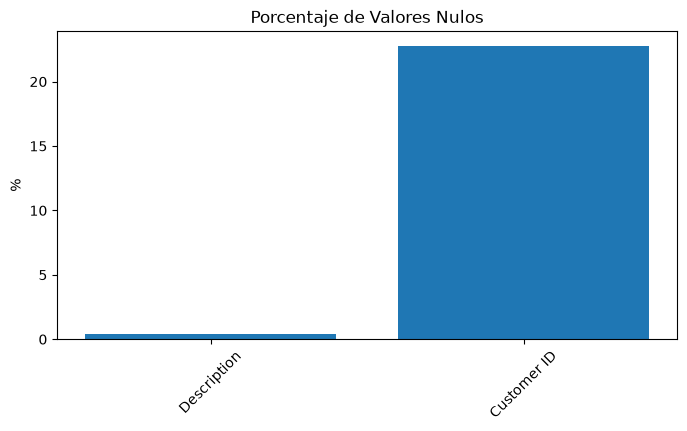

In [ ]:
# Visualización

import matplotlib.pyplot as plt

missing = missing[missing["Valores Nulos"]>0]

plt.figure(figsize=(8,4))

plt.bar(
    missing.index,
    missing["% Nulos"]
)

plt.title("Porcentaje de Valores Nulos")

plt.ylabel("%")

plt.xticks(rotation=45)

plt.show()


In [ ]:
# 3.4 Registros duplicados
duplicados = df.duplicated().sum()

print(f"Registros duplicados: {duplicados:,}")

Registros duplicados: 34,335


In [ ]:
# 3.5 Valores únicos
pd.DataFrame({
    "Valores únicos": df.nunique()
}).sort_values("Valores únicos", ascending=False)

,Valores únicos
Invoice,53628
InvoiceDate,47635
Customer ID,5942
Description,5698
StockCode,5305
Price,2807
Quantity,1057
Country,43


In [ ]:
# 3.6 Valores negativos - Cantidad
cantidad_negativa = (df["Quantity"] < 0).sum()

print(f"Cantidad negativa: {cantidad_negativa:,}")

Cantidad negativa: 22,950


In [ ]:
# 3.6 Valores negativos - Precio
precio_negativo = (df["Price"] < 0).sum()

print(f"Precio negativo: {precio_negativo:,}")

Precio negativo: 5


In [ ]:
# Precio igual a cero
precio_cero = (df["Price"] == 0).sum()

print(f"Precio igual a cero: {precio_cero:,}")

Precio igual a cero: 6,202


In [ ]:
# Facturas canceladas
# En este dataset las devoluciones comienzan con la letra C.

canceladas = df["Invoice"].astype(str).str.startswith("C").sum()

print(f"Facturas canceladas: {canceladas:,}")

print(f"Porcentaje: {canceladas/len(df)*100:.2f}%")

Facturas canceladas: 19,494
Porcentaje: 1.83%


In [ ]:
# Clientes sin identificación

clientes_sin_id = df["Customer ID"].isnull().sum()

print(f"Clientes sin ID: {clientes_sin_id:,}")

print(f"Porcentaje: {clientes_sin_id/len(df)*100:.2f}%")

Clientes sin ID: 243,007
Porcentaje: 22.77%


In [23]:
# Verificar de fechas

df["InvoiceDate"].head()

0   2009-12-01 07:45:00
1   2009-12-01 07:45:00
2   2009-12-01 07:45:00
3   2009-12-01 07:45:00
4   2009-12-01 07:45:00
Name: InvoiceDate, dtype: datetime64[us]

In [24]:
# Conversión de fechas

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["InvoiceDate"].dtype

dtype('<M8[us]')

In [ ]:
# Consistencia de los datos

(df["Quantity"] == 0).sum()

np.int64(6207)

In [26]:
(df["Price"] <= 0).sum()

np.int64(6207)

In [28]:
# Total de venta

df["Total"] = df["Quantity"] * df["Price"]

In [29]:
(df["Total"] <= 0).sum()

np.int64(25700)

In [30]:
# Estadísticas descriptivas

df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,1067371.0,9.938898,-80995.0,1.0,3.0,10.0,80995.0,172.705794
InvoiceDate,1067371,2011-01-02 21:13:55.394029,2009-12-01 07:45:00,2010-07-09 09:46:00,2010-12-07 15:28:00,2011-07-22 10:23:00,2011-12-09 12:50:00,NaN
Price,1067371.0,4.649388,-53594.36,1.25,2.1,4.15,38970.0,123.553059
Customer ID,824364.0,15324.638504,12346.0,13975.0,15255.0,16797.0,18287.0,1697.46445
Total,1067371.0,18.069866,-168469.6,3.75,9.9,17.7,168469.6,292.420223


In [31]:
# Resumen de Calidad
print("="*60)
print("RESUMEN DE CALIDAD")
print("="*60)

print(f"Registros                 : {len(df):,}")
print(f"Duplicados                : {df.duplicated().sum():,}")
print(f"Nulos                     : {df.isnull().sum().sum():,}")
print(f"Clientes sin ID           : {df['Customer ID'].isnull().sum():,}")
print(f"Facturas canceladas       : {df['Invoice'].astype(str).str.startswith('C').sum():,}")
print(f"Cantidad negativa         : {(df['Quantity']<0).sum():,}")
print(f"Cantidad igual a cero     : {(df['Quantity']==0).sum():,}")
print(f"Precio menor o igual a 0  : {(df['Price']<=0).sum():,}")

RESUMEN DE CALIDAD
Registros                 : 1,067,371
Duplicados                : 34,335
Nulos                     : 247,389
Clientes sin ID           : 243,007
Facturas canceladas       : 19,494
Cantidad negativa         : 22,950
Cantidad igual a cero     : 0
Precio menor o igual a 0  : 6,207


# Análisis de la Calidad de los Datos

El análisis de calidad del conjunto de datos permitió identificar las principales inconsistencias que deberán ser tratadas antes de construir el modelo de segmentación de clientes y el sistema de recomendaciones.

## Resumen de Calidad

| Indicador | Valor |
|-----------|------:|
| Registros totales | **1.067.371** |
| Registros duplicados | **34.335** |
| Valores nulos | **247.389** |
| Clientes sin identificación (Customer ID) | **243.007** |
| Facturas canceladas | **19.494** |
| Cantidades negativas | **22.950** |
| Cantidades iguales a cero | **0** |
| Precios menores o iguales a cero | **6.207** |

---

## Análisis de los resultados

### Registros duplicados

Se identificaron **34.335 registros duplicados**, lo que representa aproximadamente el **3,22 %** del conjunto de datos.

Estos registros pueden generar una sobreestimación de las ventas, la frecuencia de compra y el valor monetario de los clientes, por lo que deberán eliminarse durante la etapa de limpieza.

---

### Valores faltantes

El conjunto de datos presenta **247.389 valores faltantes**, concentrados principalmente en las variables **Customer ID** y **Description**.

La mayor parte de los datos faltantes corresponde a la variable **Customer ID**, la cual contiene **243.007 registros sin identificar** (22,77 % del total).

---

### Clientes sin identificación

La ausencia del identificador del cliente constituye el principal desafío del proyecto.

Dado que el modelo requiere construir un historial de compras para cada cliente, estos registros **no podrán utilizarse para el proceso de segmentación**.

Sin embargo, estas transacciones sí podrán ser aprovechadas durante el análisis exploratorio y en la construcción de reglas de asociación mediante **FP-Growth**, ya que este algoritmo trabaja sobre las facturas y los productos comprados, sin depender de la identificación del cliente.

---

### Facturas canceladas

Se identificaron **19.494 facturas canceladas**, las cuales se reconocen porque el número de factura comienza con la letra **"C"**.

Estas transacciones corresponden a devoluciones de productos y generan cantidades negativas dentro del conjunto de datos.

Su tratamiento dependerá del objetivo del análisis; sin embargo, para la construcción del modelo RFM se recomienda excluirlas, ya que no representan compras efectivas del cliente.

---

### Cantidades negativas

Se encontraron **22.950 registros con cantidades negativas**.

Este comportamiento está directamente relacionado con las devoluciones registradas en las facturas canceladas.

Antes del entrenamiento del modelo será necesario validar que todos estos registros correspondan efectivamente a devoluciones y definir si deben eliminarse o analizarse por separado.

---

### Cantidades iguales a cero

No se encontraron registros con cantidades iguales a cero.

Esto indica que todas las transacciones representan movimientos reales de inventario, ya sean compras o devoluciones.

---

### Precios menores o iguales a cero

Se identificaron **6.207 registros con precios menores o iguales a cero**.

Estos registros pueden corresponder a:

- Productos promocionales.
- Muestras gratuitas.
- Errores de captura.
- Ajustes administrativos.

Será necesario revisar estos casos antes del modelado, ya que podrían afectar el cálculo.

---

# Impacto sobre el proyecto

Con base en este análisis se establecen las siguientes decisiones para la fase de preparación de datos:

| Problema identificado | Acción propuesta |
|------------------------|------------------|
| Registros duplicados | Eliminar duplicados. |
| Customer ID nulo | Excluir únicamente para la construcción del modelo. |
| Description nula | Evaluar su eliminación o mantener el registro si no afecta el análisis. |
| Facturas canceladas | Excluir del modelo; conservar para análisis de devoluciones si es necesario. |
| Cantidades negativas | Validar su relación con devoluciones y excluir del modelo de segmentación. |
| Precio menor o igual a cero | Revisar caso a caso y excluir aquellos que no representen ventas reales. |

---

# Conclusiones

La calidad general del conjunto de datos es adecuada para el desarrollo del proyecto. No obstante, se identificaron algunos aspectos que requieren tratamiento previo al modelado:

- El porcentaje de registros duplicados es bajo y puede corregirse fácilmente.
- La ausencia del **Customer ID** en el **22,77 %** de las transacciones limita el uso de estos registros para la segmentación de clientes, aunque no afecta el análisis mediante reglas de asociación.
- Las devoluciones representan una parte importante del conjunto de datos y deberán tratarse de manera independiente para evitar sesgos en el cálculo de las variables.
- Después del proceso de limpieza, el conjunto de datos conservará un volumen suficiente de información para construir un modelo robusto de segmentación y un sistema de recomendación basado en patrones de compra.

# 4. Limpieza de los Datos

## Objetivo

El objetivo de esta etapa es preparar un conjunto de datos consistente y confiable para la construcción del modelo de segmentación de clientes y del sistema de recomendaciones .

Con base en el análisis de calidad realizado anteriormente, se aplicarán los siguientes criterios de limpieza:

- Eliminar registros duplicados.
- Eliminar registros sin **Customer ID**.
- Eliminar facturas canceladas.
- Eliminar registros con cantidades negativas.
- Eliminar registros con precio igual a cero.

Al finalizar esta etapa se obtendrá un conjunto de datos limpio, listo para el proceso de ingeniería de características y modelado.

In [41]:
# Número inicial de registros
registros_iniciales = len(df)

# Duplicados
duplicados = df.duplicated().sum()

# Customer ID nulos
customer_id_nulos = df["Customer ID"].isnull().sum()

# Facturas canceladas
facturas_canceladas = df["Invoice"].astype(str).str.startswith("C").sum()

# Cantidades negativas
cantidades_negativas = (df["Quantity"] < 0).sum()

# Precio igual a cero
precio_cero = (df["Price"] == 0).sum()

In [32]:
# Copia del dataset original
df_clean = df.copy()

print(f"Registros iniciales: {len(df_clean):,}")


Registros iniciales: 1,067,371


## Eliminación de registros duplicados

Los registros duplicados representan transacciones repetidas que pueden generar una sobreestimación de las ventas y afectar el cálculo de las variables.

Por esta razón, todos los registros duplicados serán eliminados.

In [33]:
duplicados = df_clean.duplicated().sum()

print(f"Duplicados encontrados: {duplicados:,}")

df_clean.drop_duplicates(inplace=True)

print(f"Registros después de eliminar duplicados: {len(df_clean):,}")

Duplicados encontrados: 34,335
Registros después de eliminar duplicados: 1,033,036


## Eliminación de registros sin Customer ID

El modelo requiere identificar de manera única cada cliente para calcular su comportamiento de compra.

Por esta razón, se eliminarán los registros que no contienen información en la variable **Customer ID**.

In [34]:
sin_cliente = df_clean["Customer ID"].isna().sum()

print(f"Clientes sin ID: {sin_cliente:,}")

df_clean = df_clean[df_clean["Customer ID"].notna()]

print(f"Registros después de eliminar Customer ID nulos: {len(df_clean):,}")

Clientes sin ID: 235,151
Registros después de eliminar Customer ID nulos: 797,885


## Eliminación de facturas canceladas

Las facturas cuyo número inicia con la letra **"C"** corresponden a devoluciones de productos.

Estas transacciones no representan compras efectivas y pueden alterar el cálculo del gasto total y la frecuencia de compra del cliente.

Por esta razón, serán excluidas del conjunto de datos utilizado para el modelo de segmentación.

In [35]:
canceladas = df_clean["Invoice"].astype(str).str.startswith("C").sum()

print(f"Facturas canceladas: {canceladas:,}")

df_clean = df_clean[
    ~df_clean["Invoice"].astype(str).str.startswith("C")
]

print(f"Registros después de eliminar cancelaciones: {len(df_clean):,}")

Facturas canceladas: 18,390
Registros después de eliminar cancelaciones: 779,495


## Eliminación de cantidades negativas

Las cantidades negativas corresponden principalmente a devoluciones y ajustes de inventario.

Dado que el objetivo del proyecto es analizar el comportamiento de compra de los clientes, estos registros serán eliminados.

In [36]:
cantidad_negativa = (df_clean["Quantity"] < 0).sum()

print(f"Cantidad negativa: {cantidad_negativa:,}")

df_clean = df_clean[df_clean["Quantity"] > 0]

print(f"Registros después de eliminar cantidades negativas: {len(df_clean):,}")

Cantidad negativa: 0
Registros después de eliminar cantidades negativas: 779,495


## Eliminación de precios iguales a cero

Los registros con precio igual a cero no representan ventas comerciales y pueden afectar el cálculo del valor monetario del cliente.

Por esta razón, serán eliminados del conjunto de datos.

In [37]:
precio_cero = (df_clean["Price"] == 0).sum()

print(f"Precio igual a cero: {precio_cero:,}")

df_clean = df_clean[df_clean["Price"] > 0]

print(f"Registros después de eliminar precios iguales a cero: {len(df_clean):,}")

Precio igual a cero: 70
Registros después de eliminar precios iguales a cero: 779,425


In [38]:
# Reiniciar índices
df_clean.reset_index(drop=True, inplace=True)

In [39]:
# Validación
print("="*60)
print("VALIDACIÓN DEL DATASET LIMPIO")
print("="*60)

print(f"Registros: {len(df_clean):,}")

print(f"Duplicados: {df_clean.duplicated().sum():,}")

print(f"Customer ID nulos: {df_clean['Customer ID'].isnull().sum():,}")

print(f"Facturas canceladas: {df_clean['Invoice'].astype(str).str.startswith('C').sum():,}")

print(f"Cantidad negativa: {(df_clean['Quantity']<0).sum():,}")

print(f"Precio igual a cero: {(df_clean['Price']==0).sum():,}")

VALIDACIÓN DEL DATASET LIMPIO
Registros: 779,425
Duplicados: 0
Customer ID nulos: 0
Facturas canceladas: 0
Cantidad negativa: 0
Precio igual a cero: 0


In [40]:
# Comparación antes y después

resumen = pd.DataFrame({
    "Indicador": [
        "Registros",
        "Duplicados",
        "Customer ID nulos",
        "Facturas canceladas",
        "Cantidad negativa",
        "Precio igual a cero"
    ],
    "Antes": [
        len(df),
        df.duplicated().sum(),
        df["Customer ID"].isnull().sum(),
        df["Invoice"].astype(str).str.startswith("C").sum(),
        (df["Quantity"] < 0).sum(),
        (df["Price"] == 0).sum()
    ],
    "Después": [
        len(df_clean),
        df_clean.duplicated().sum(),
        df_clean["Customer ID"].isnull().sum(),
        df_clean["Invoice"].astype(str).str.startswith("C").sum(),
        (df_clean["Quantity"] < 0).sum(),
        (df_clean["Price"] == 0).sum()
    ]
})

resumen

,Indicador,Antes,Después
0,Registros,1067371,779425
1,Duplicados,34335,0
2,Customer ID nulos,243007,0
3,Facturas canceladas,19494,0
4,Cantidad negativa,22950,0
5,Precio igual a cero,6202,0


In [42]:
registros_finales = len(df_clean)

total_eliminados = registros_iniciales - registros_finales

resumen_limpieza = pd.DataFrame({
    "Acción": [
        "Eliminar registros duplicados",
        "Eliminar Customer ID nulos",
        "Eliminar facturas canceladas",
        "Eliminar cantidades negativas",
        "Eliminar precio igual a cero",
        "Total de registros eliminados",
        "Registros finales"
    ],
    "Registros": [
        duplicados,
        customer_id_nulos,
        facturas_canceladas,
        cantidades_negativas,
        precio_cero,
        total_eliminados,
        registros_finales
    ]
})

resumen_limpieza

,Acción,Registros
0,Eliminar registros duplicados,34335
1,Eliminar Customer ID nulos,243007
2,Eliminar facturas canceladas,19494
3,Eliminar cantidades negativas,22950
4,Eliminar precio igual a cero,6202
5,Total de registros eliminados,287946
6,Registros finales,779425


In [43]:
registros_iniciales = len(df)
registros_finales = len(df_clean)
registros_eliminados = registros_iniciales - registros_finales

resumen_final = pd.DataFrame({
    "Indicador": [
        "Registros iniciales",
        "Registros eliminados",
        "Registros finales",
        "Porcentaje de registros conservados"
    ],
    "Valor": [
        f"{registros_iniciales:,}",
        f"{registros_eliminados:,}",
        f"{registros_finales:,}",
        f"{(registros_finales/registros_iniciales)*100:.2f}%"
    ]
})

display(resumen_final)

,Indicador,Valor
0,Registros iniciales,"1,067,371"
1,Registros eliminados,"287,946"
2,Registros finales,"779,425"
3,Porcentaje de registros conservados,73.02%


## Resumen del Proceso de Limpieza

La siguiente tabla presenta las reglas de limpieza definidas para el proyecto y el impacto esperado sobre el conjunto de datos.

| Regla de limpieza | Registros afectados | % del dataset | Justificación |
|-------------------|--------------------:|--------------:|---------------|
| Eliminar registros duplicados | 34.335 | 3,22 % | Evitar duplicidad de transacciones y sobreestimación de ventas. |
| Eliminar registros con **Customer ID** nulo | 243.007 | 22,77 % | No es posible construir las variables sin identificar al cliente. |
| Eliminar facturas canceladas | 19.494 | 1,83 % | Corresponden a devoluciones y no representan compras efectivas. |
| Eliminar cantidades negativas | 22.950 | 2,15 % | Representan devoluciones o ajustes de inventario. |
| Eliminar precios iguales a cero | 6.207 | 0,58 % | No representan ventas comerciales y afectan el cálculo del valor monetario. |

> **Importante:** Los valores anteriores **no son acumulables**, ya que un mismo registro puede cumplir varias reglas de limpieza (por ejemplo, una factura cancelada también presenta una cantidad negativa). Por esta razón, el número total de registros eliminados se calculará comparando el tamaño del conjunto de datos antes y después del proceso de limpieza.

### Resultado Final del Proceso de Limpieza

| Indicador | Valor |
|-----------|------:|
| Registros iniciales | **1.067.371** |
| Registros eliminados | **287.946** |
| Registros finales | **779.425** |
| Porcentaje de registros conservados | **73.02%** |
| Dataset listo para Feature Engineering | ✅ |

# Arquitectura del Sistema de Recomendación basado en FP-Growth

```mermaid
flowchart TD

A[📂 Online Retail II<br>1.067.371 registros]

A --> B[EDA]

B --> C[Limpieza de Datos]

C --> D[Eliminar duplicados]

D --> E[Eliminar Customer ID nulos]

E --> F[Eliminar facturas canceladas]

F --> G[Eliminar cantidades negativas]

G --> H[Eliminar precios iguales a cero]

H --> I[Dataset Limpio]

I --> J[Construcción de Transacciones<br>Invoice → Productos]

J --> K[Transaction Encoder]

K --> L[FP-Growth]

L --> M[Reglas de Asociación]

M --> N[Motor de Recomendaciones]

N --> O[FastAPI]

O --> P[Streamlit]

P --> Q[Usuario Final]
```

```text
                  Online Retail II
                 (1.067.371 registros)
                          │
                          ▼
                 Análisis Exploratorio
                        (EDA)
                          │
                          ▼
                 Limpieza de Datos
                          │
        ┌─────────────────┼─────────────────┐
        │                 │                 │
        ▼                 ▼                 ▼
 Eliminar          Eliminar          Eliminar
 duplicados      Customer ID      devoluciones
                                    y precios
                          │
                          ▼
                  Dataset Procesado
                          │
                          ▼
            Construcción de Transacciones
               (Factura → Productos)
                          │
                          ▼
                Transaction Encoder
                          │
                          ▼
                     FP-Growth
                          │
                          ▼
              Reglas de Asociación
                          │
                          ▼
            Motor de Recomendaciones
                          │
                          ▼
                     FastAPI
                          │
                          ▼
                    Streamlit
                          │
                          ▼
                   Usuario Final
```

# 5. Análisis Univariado

## Objetivo

El análisis univariado tiene como propósito estudiar el comportamiento individual de cada variable del conjunto de datos limpio, identificando su distribución, valores representativos y posibles anomalías.

Este análisis permitirá comprender mejor las características de las transacciones y servirá como base para la construcción del sistema de recomendación mediante **FP-Growth**.

En esta sección se analizarán las siguientes variables:

- Quantity
- Price
- Country
- StockCode
- Description
- InvoiceDate

## 5.1 Cantidad de productos vendidos (Quantity)

La variable **Quantity** representa el número de unidades compradas por producto en cada transacción.

Su análisis permite identificar:

- Cantidad promedio comprada.
- Distribución de las compras.
- Existencia de valores atípicos.
- Productos adquiridos en grandes volúmenes.

In [44]:
df_clean["Quantity"].describe()

count    779425.000000
mean         13.489370
std         145.855814
min           1.000000
25%           2.000000
50%           6.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

In [50]:
df_clean["Quantity"].describe(
    percentiles=[0.25,0.50,0.75,0.90,0.95,0.99]
)

count    779425.000000
mean         13.489370
std         145.855814
min           1.000000
25%           2.000000
50%           6.000000
75%          12.000000
90%          24.000000
95%          36.000000
99%         144.000000
max       80995.000000
Name: Quantity, dtype: float64

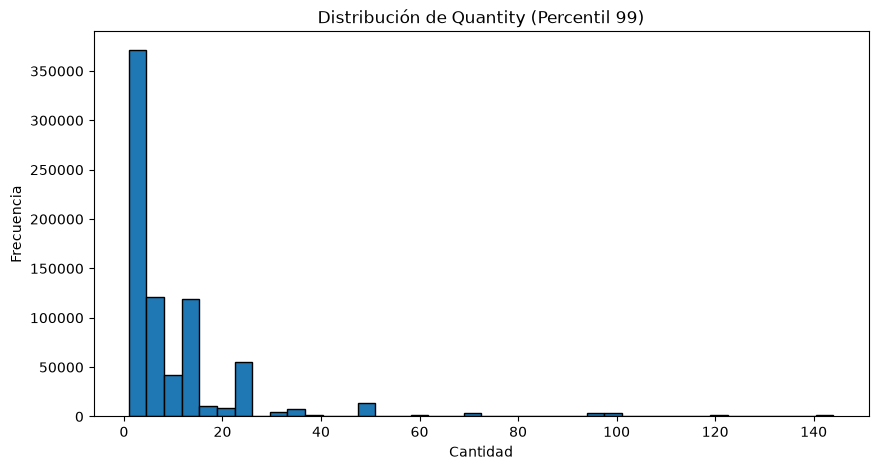

In [47]:
# Percentil 99
p99 = df_clean["Quantity"].quantile(0.99)

plt.figure(figsize=(10,5))

plt.hist(
    df_clean[df_clean["Quantity"] <= p99]["Quantity"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribución de Quantity (Percentil 99)")
plt.xlabel("Cantidad")
plt.ylabel("Frecuencia")

plt.show()

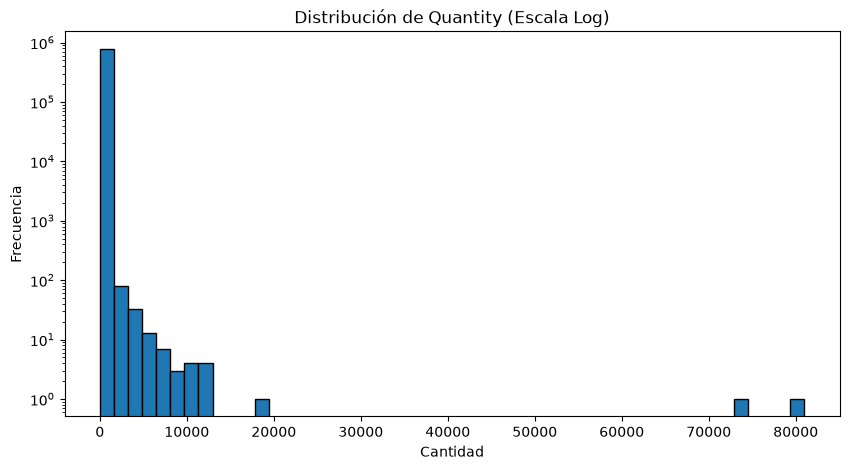

In [49]:
plt.figure(figsize=(10,5))

plt.hist(
    df_clean["Quantity"],
    bins=50,
    log=True,
    edgecolor="black"
)

plt.title("Distribución de Quantity (Escala Log)")
plt.xlabel("Cantidad")
plt.ylabel("Frecuencia")

plt.show()

### Análisis de la variable Quantity

La distribución de la variable **Quantity** presenta una fuerte asimetría positiva. La mayoría de las transacciones corresponden a compras de pocas unidades, mientras que un número reducido de operaciones registra cantidades excepcionalmente altas.

Estos valores extremos son característicos de este conjunto de datos, ya que la empresa comercializa productos tanto a clientes minoristas como a mayoristas.

Con el fin de visualizar adecuadamente la distribución, se emplea un histograma limitado al percentil 99, evitando que los valores atípicos oculten el comportamiento de la mayoría de las observaciones.

Es importante destacar que **los valores extremos no serán eliminados automáticamente**, ya que pueden representar compras reales de alto volumen y aportar información relevante para el análisis del comportamiento de compra.

# Análisis del Tamaño de la Cesta de Compra (Basket Size)

## Objetivo

El **Basket Size** representa el número de productos diferentes incluidos en una misma factura (Invoice).

Este indicador permite comprender el comportamiento de compra de los clientes y evaluar si el conjunto de datos es adecuado para la aplicación del algoritmo **FP-Growth**, el cual identifica reglas de asociación entre productos comprados conjuntamente.

El análisis responderá preguntas como:

- ¿Cuántos productos compra un cliente en promedio por transacción?
- ¿Cuál es el tamaño promedio de una cesta de compra?
- ¿Existen compras muy grandes que puedan afectar el modelo?
- ¿El dataset contiene suficiente información para descubrir asociaciones entre productos?

In [51]:
# Número de productos diferentes por factura
basket_size = (
    df_clean
    .groupby("Invoice")["StockCode"]
    .nunique()
    .reset_index()
)

basket_size.columns = ["Invoice", "Basket_Size"]

basket_size.head()

,Invoice,Basket_Size
0,489434,8
1,489435,4
2,489436,19
3,489437,23
4,489438,17


In [52]:
basket_size["Basket_Size"].describe()

count    36969.000000
mean        20.797560
std         22.399873
min          1.000000
25%          6.000000
50%         15.000000
75%         27.000000
max        541.000000
Name: Basket_Size, dtype: float64

In [53]:
basket_size["Basket_Size"].describe(
    percentiles=[0.25,0.50,0.75,0.90,0.95,0.99]
)

count    36969.000000
mean        20.797560
std         22.399873
min          1.000000
25%          6.000000
50%         15.000000
75%         27.000000
90%         46.000000
95%         61.000000
99%        101.000000
max        541.000000
Name: Basket_Size, dtype: float64

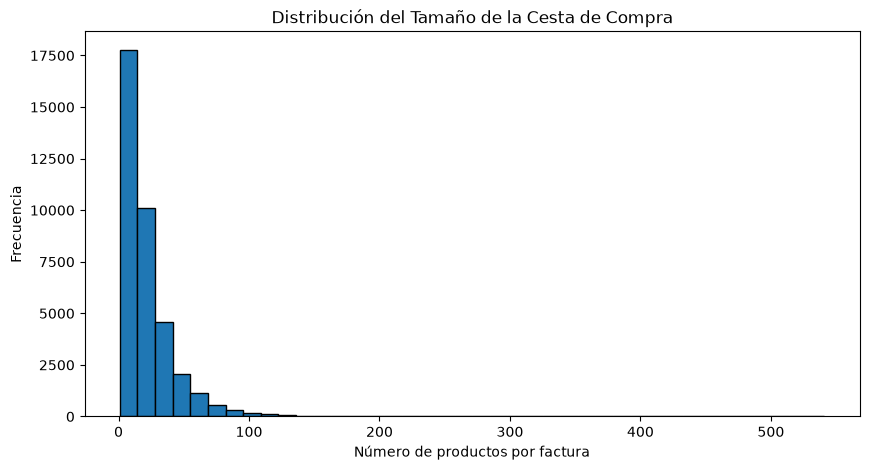

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    basket_size["Basket_Size"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribución del Tamaño de la Cesta de Compra")

plt.xlabel("Número de productos por factura")

plt.ylabel("Frecuencia")

plt.show()

C:\Users\druiz\AppData\Local\Temp\ipykernel_20088\3288826506.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


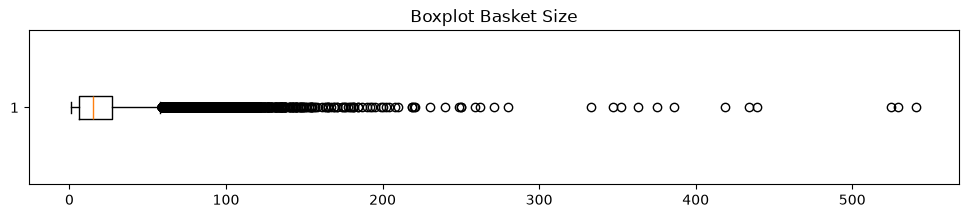

In [55]:
plt.figure(figsize=(12,2))

plt.boxplot(
    basket_size["Basket_Size"],
    vert=False
)

plt.title("Boxplot Basket Size")

plt.show()

In [57]:
print(f"Tamaño promedio de la cesta: {basket_size['Basket_Size'].mean():.2f}")
print(f"Mediana: {basket_size['Basket_Size'].median():.0f}")

Tamaño promedio de la cesta: 20.80
Mediana: 15


In [58]:
basket_size.sort_values(
    "Basket_Size",
    ascending=False
).head(10)

,Invoice,Basket_Size
34676,576339,541
35957,579196,529
36598,580727,525
35562,578270,439
33515,573576,434
30949,567656,419
30761,567183,386
34330,575607,375
32594,571441,363
33040,572552,352


In [59]:
basket_size["Basket_Size"].value_counts().sort_index()

Basket_Size
1      3072
2      1411
3      1245
4      1215
5      1229
       ... 
434       1
439       1
525       1
529       1
541       1
Name: count, Length: 207, dtype: int64

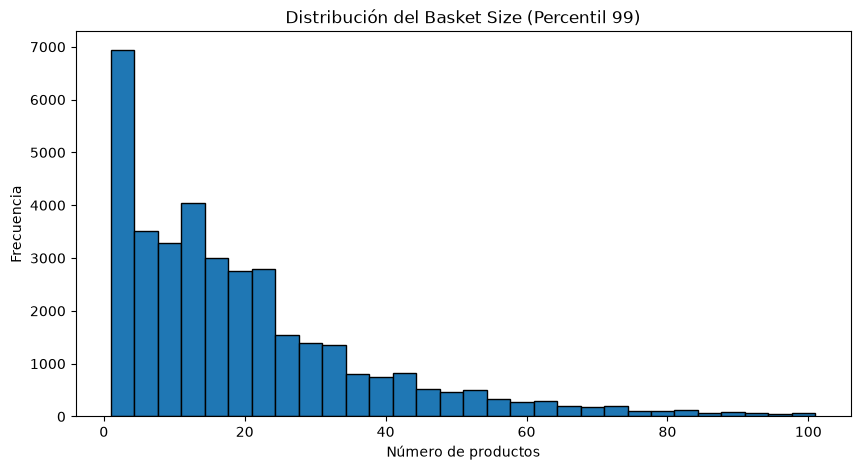

In [60]:
p99 = basket_size["Basket_Size"].quantile(0.99)

plt.figure(figsize=(10,5))

plt.hist(
    basket_size[
        basket_size["Basket_Size"] <= p99
    ]["Basket_Size"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribución del Basket Size (Percentil 99)")

plt.xlabel("Número de productos")

plt.ylabel("Frecuencia")

plt.show()

In [61]:
resumen_basket = pd.DataFrame({
    "Indicador":[
        "Número de facturas",
        "Promedio Basket Size",
        "Mediana",
        "Máximo",
        "Mínimo"
    ],
    "Valor":[
        basket_size.shape[0],
        round(basket_size["Basket_Size"].mean(),2),
        basket_size["Basket_Size"].median(),
        basket_size["Basket_Size"].max(),
        basket_size["Basket_Size"].min()
    ]
})

display(resumen_basket)

,Indicador,Valor
0,Número de facturas,36969.0
1,Promedio Basket Size,20.8
2,Mediana,15.0
3,Máximo,541.0
4,Mínimo,1.0


## Análisis del Tamaño de la Cesta de Compra (Basket Size)

El **Basket Size** representa el número de productos diferentes incluidos en cada factura y constituye una de las métricas más importantes para un sistema de recomendación basado en **FP-Growth**, ya que cada factura corresponde a una transacción sobre la cual se descubrirán las reglas de asociación entre productos.

### Resumen estadístico

| Indicador | Valor |
|-----------|------:|
| Número de facturas | **36.969** |
| Tamaño promedio de la cesta | **20,8 productos** |
| Mediana | **15 productos** |
| Mínimo | **1 producto** |
| Máximo | **541 productos** |

---

### Interpretación de los resultados

El conjunto de datos contiene **36.969 transacciones**, las cuales serán utilizadas como entrada para el algoritmo **FP-Growth**.

El **tamaño promedio de la cesta de compra es de 20,8 productos por factura**, lo que indica que los clientes suelen adquirir varios artículos en una misma compra. Esta característica incrementa el número de combinaciones posibles entre productos y favorece el descubrimiento de reglas de asociación con alto valor comercial.

La **mediana de 15 productos** muestra que el 50 % de las transacciones contienen hasta 15 productos diferentes. Como la media es superior a la mediana, se evidencia una **distribución asimétrica positiva**, ocasionada por un grupo reducido de facturas con un número muy elevado de productos.

El **máximo de 541 productos** confirma la existencia de compras de gran volumen, probablemente realizadas por clientes mayoristas, lo cual es consistente con la naturaleza del negocio descrita en el dataset. Estas transacciones aportan una amplia variedad de combinaciones de productos, aunque también pueden influir significativamente en la generación de reglas de asociación.

Por otra parte, el valor mínimo de **1 producto por factura** indica que también existen compras individuales, las cuales aportan menos información para descubrir asociaciones entre artículos.

---

### Implicaciones para el modelo

Los resultados obtenidos permiten concluir que el conjunto de datos presenta condiciones favorables para implementar un sistema de recomendación, debido a que:

- Se dispone de un número elevado de transacciones (**36.969 facturas**).
- Cada factura contiene, en promedio, más de **20 productos**, proporcionando una gran cantidad de combinaciones entre artículos.
- Existe suficiente diversidad en el tamaño de las cestas de compra para identificar patrones de consumo frecuentes.
- La presencia de compras mayoristas incrementa la posibilidad de descubrir reglas de asociación relevantes entre productos.

En consecuencia, el conjunto de datos ofrece una base sólida para construir un sistema de recomendación capaz de identificar productos que suelen comprarse conjuntamente y generar recomendaciones útiles para estrategias de **Cross Selling** y **Up Selling**.

# 6. Análisis Bivariado

## Objetivo

El análisis bivariado tiene como propósito estudiar la relación entre dos variables del conjunto de datos para identificar patrones de compra relevantes que permitan comprender el comportamiento de los clientes y los productos.

En esta etapa se analizarán las relaciones entre:

- País y ventas.
- Productos y cantidad vendida.
- Productos e ingresos.
- Clientes y frecuencia de compra.
- Clientes y gasto total.
- Facturas y número de productos.
- Productos comprados conjuntamente.

Los resultados obtenidos servirán como base para la construcción del sistema de recomendación mediante.

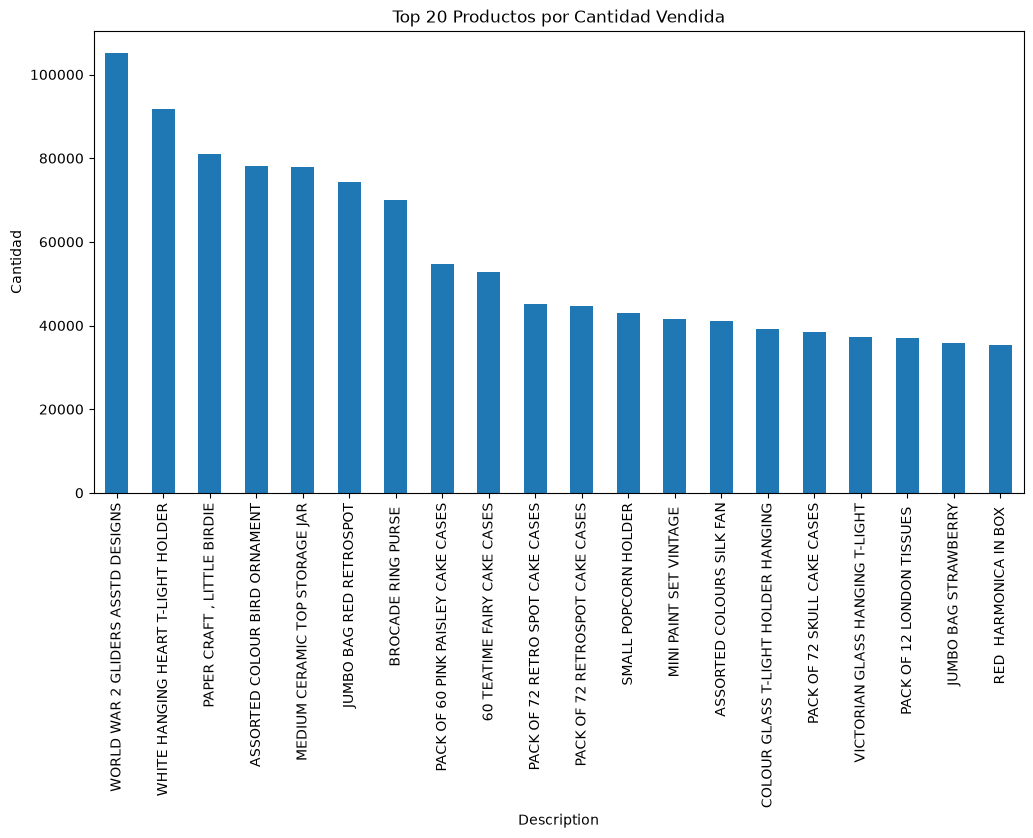

In [ ]:
# Top 20 Productos más vendidos

top_productos = (
    df_clean
    .groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,6))

top_productos.plot(kind="bar")

plt.title("Top 20 Productos por Cantidad Vendida")

plt.ylabel("Cantidad")

plt.show()

In [63]:
df_clean["Total"] = df_clean["Quantity"] * df_clean["Price"]

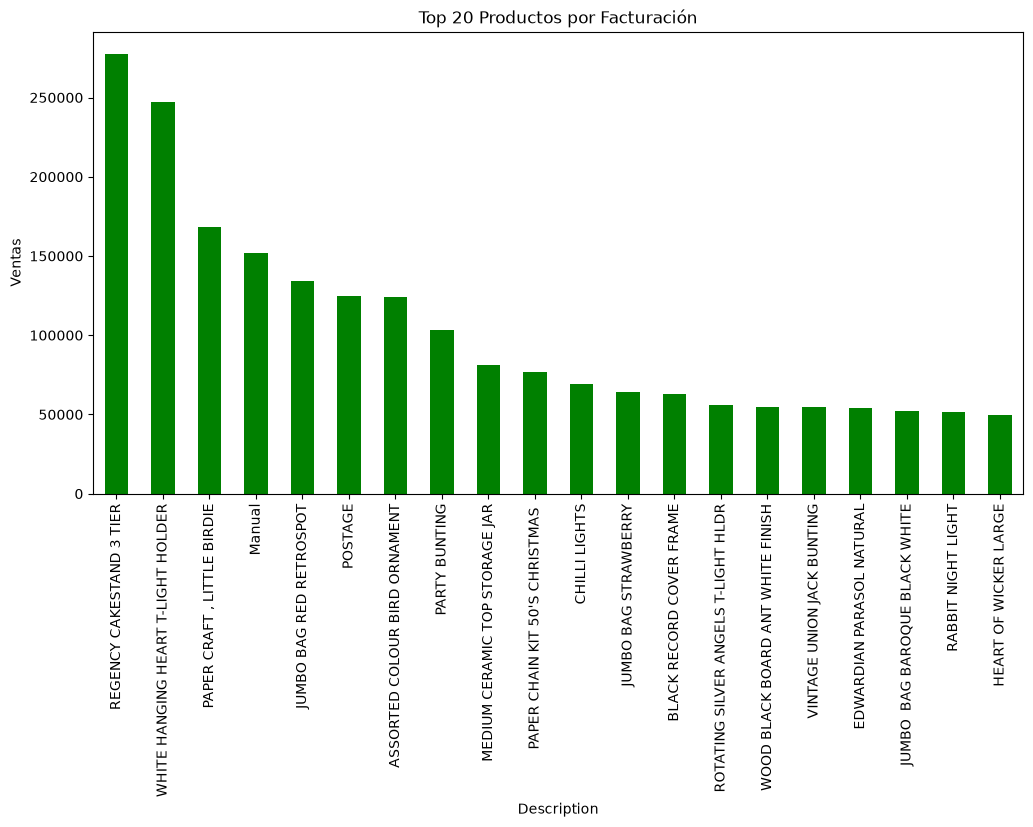

In [ ]:
# Productos con mayor facturación
ventas_producto = (
    df_clean
    .groupby("Description")["Total"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,6))

ventas_producto.plot(kind="bar", color="green")

plt.title("Top 20 Productos por Facturación")

plt.ylabel("Ventas")

plt.show()

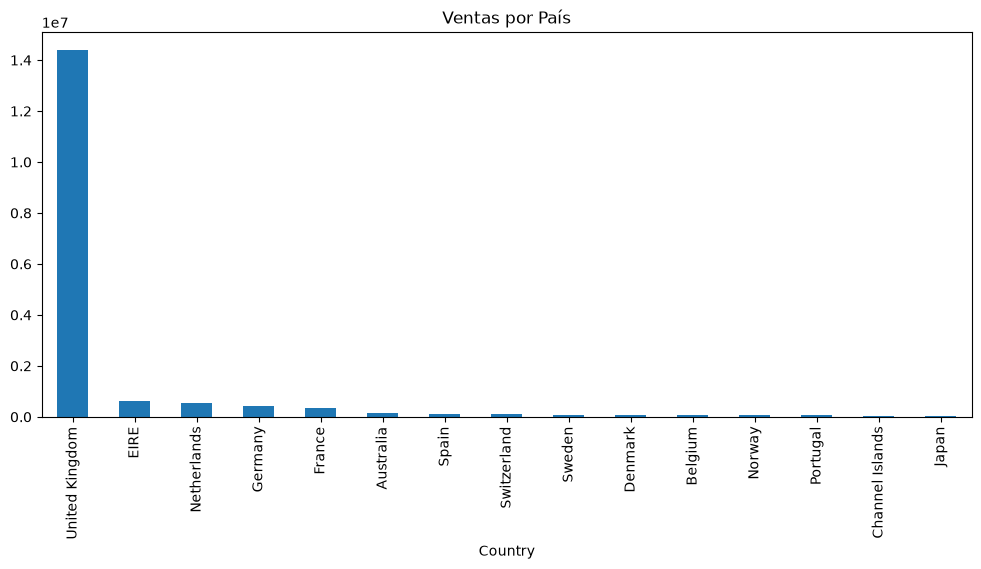

In [ ]:
# Países con mayor facturación
ventas_pais = (
    df_clean
    .groupby("Country")["Total"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,5))

ventas_pais.plot(kind="bar")

plt.title("Ventas por País")

plt.show()

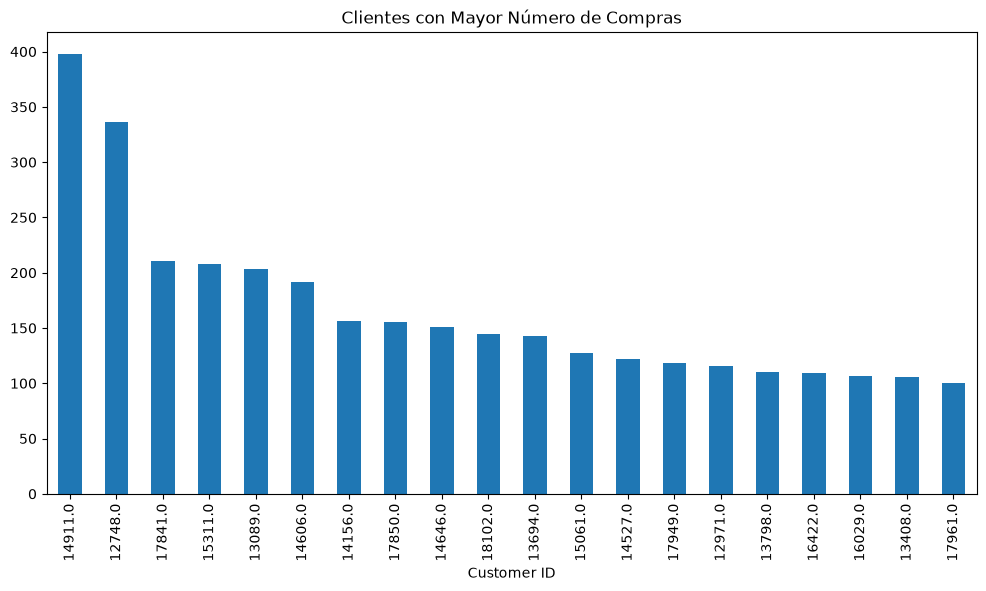

In [ ]:
# Clientes con mayor frecuencia

clientes_frecuencia = (
    df_clean
    .groupby("Customer ID")["Invoice"]
    .nunique()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,6))

clientes_frecuencia.plot(kind="bar")

plt.title("Clientes con Mayor Número de Compras")

plt.show()

In [67]:
# Clientes con mayor frecuencia

# matriz de transacciones.

basket = (
    df_clean
    .groupby(["Invoice","Description"])["Quantity"]
    .sum()
    .unstack()
    .fillna(0)
)

In [69]:
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)

In [70]:
productos = basket.sum().sort_values(ascending=False).head(20)

productos

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS      105185.0
WHITE HANGING HEART T-LIGHT HOLDER      91757.0
PAPER CRAFT , LITTLE BIRDIE             80995.0
ASSORTED COLOUR BIRD ORNAMENT           78234.0
MEDIUM CERAMIC TOP STORAGE JAR          77916.0
JUMBO BAG RED RETROSPOT                 74224.0
BROCADE RING PURSE                      70082.0
PACK OF 60 PINK PAISLEY CAKE CASES      54592.0
60 TEATIME FAIRY CAKE CASES             52828.0
PACK OF 72 RETRO SPOT CAKE CASES        45129.0
PACK OF 72 RETROSPOT CAKE CASES         44721.0
SMALL POPCORN HOLDER                    42955.0
MINI PAINT SET VINTAGE                  41507.0
ASSORTED COLOURS SILK FAN               40994.0
COLOUR GLASS T-LIGHT HOLDER HANGING     39259.0
PACK OF 72 SKULL CAKE CASES             38530.0
VICTORIAN GLASS HANGING T-LIGHT         37285.0
PACK OF 12 LONDON TISSUES               37084.0
JUMBO BAG STRAWBERRY                    35842.0
RED  HARMONICA IN BOX                   35229.0
dtype: float64

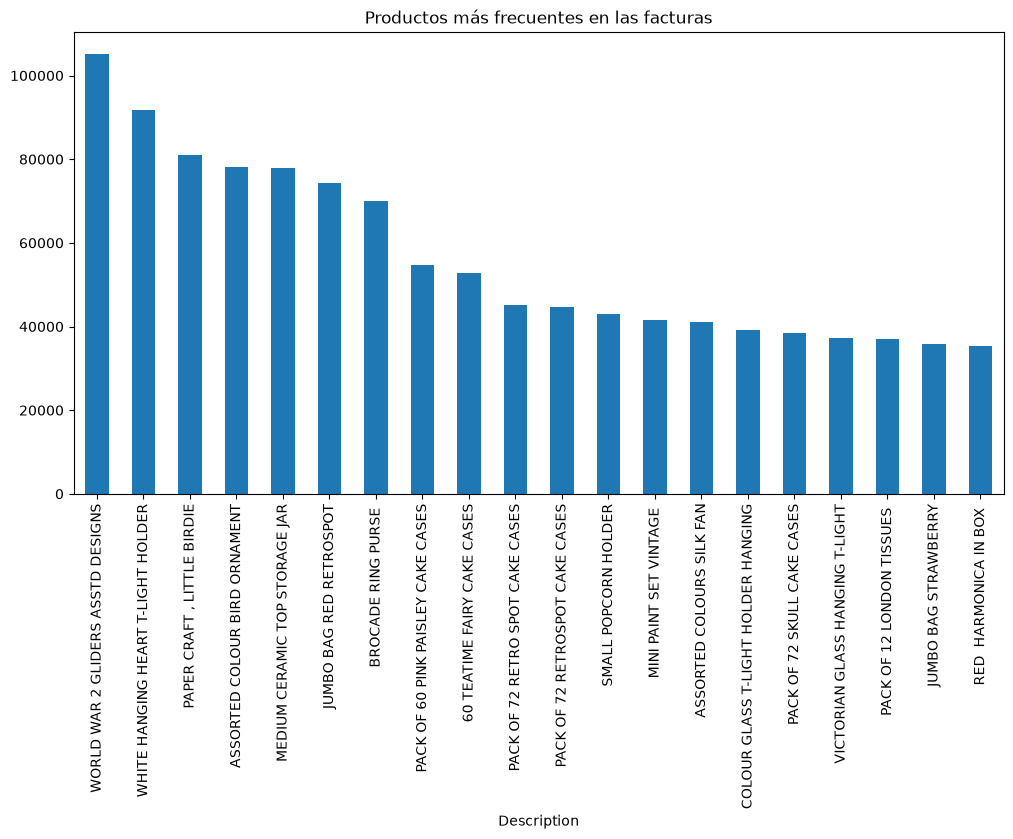

In [71]:
plt.figure(figsize=(12,6))

productos.plot(kind="bar")

plt.title("Productos más frecuentes en las facturas")

plt.show()

In [79]:
import numpy as np

coocurrencia = basket[top20].T.dot(basket[top20])

matriz = coocurrencia.to_numpy(copy=True)

np.fill_diagonal(matriz, 0)

coocurrencia = pd.DataFrame(
    matriz,
    index=coocurrencia.index,
    columns=coocurrencia.columns
)

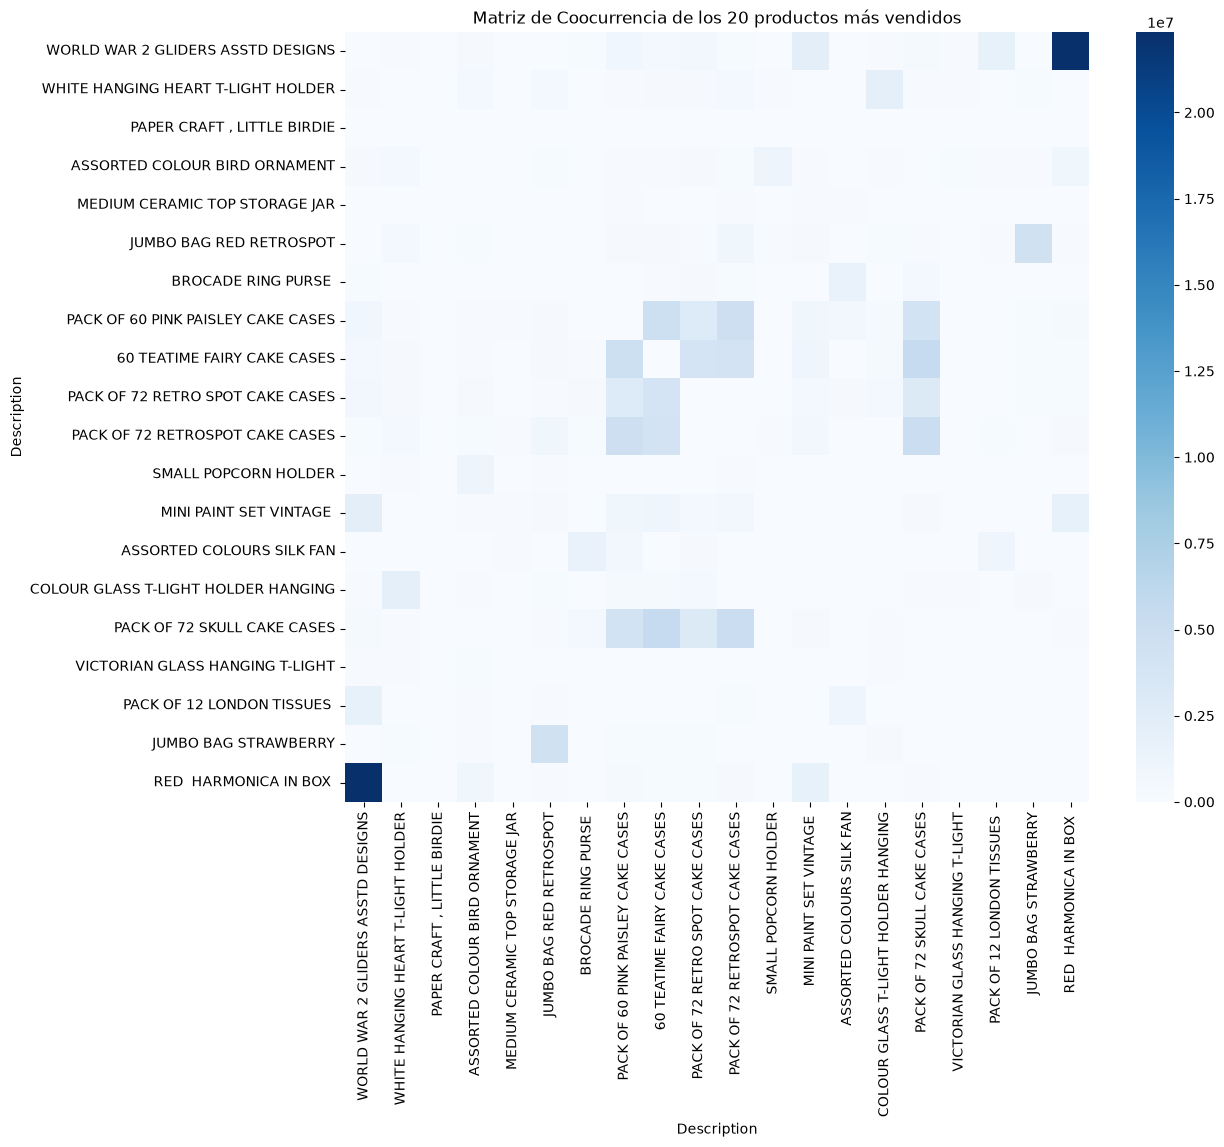

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

sns.heatmap(
    coocurrencia,
    cmap="Blues",
    annot=False
)

plt.title("Matriz de Coocurrencia de los 20 productos más vendidos")
plt.show()

# Conclusiones del Análisis Bivariado

El análisis bivariado permitió identificar relaciones importantes entre productos, clientes y mercados, proporcionando evidencia de que el conjunto de datos es adecuado para desarrollar un sistema de recomendación basado en **FP-Growth**.

##  Productos con mayor cantidad vendida

El análisis de la cantidad vendida muestra que existe un grupo reducido de productos con una demanda significativamente superior al resto del catálogo.

Los productos con mayor volumen de ventas son:

- WORLD WAR 2 GLIDERS ASSTD DESIGNS
- WHITE HANGING HEART T-LIGHT HOLDER
- PAPER CRAFT, LITTLE BIRDIE
- ASSORTED COLOUR BIRD ORNAMENT
- MEDIUM CERAMIC TOP STORAGE JAR

Este comportamiento evidencia una distribución típica del comercio minorista, donde un pequeño porcentaje de productos concentra gran parte de las unidades comercializadas.

Desde la perspectiva del sistema de recomendación, estos productos representan candidatos naturales para formar reglas de asociación, debido a su alta frecuencia de aparición en las transacciones.

---

##  Productos con mayor facturación

Al analizar los ingresos generados por producto se observa un comportamiento diferente al volumen de ventas.

Aunque algunos productos aparecen en ambos rankings, otros generan una mayor facturación debido a su precio unitario más elevado.

Destacan productos como:

- REGENCY CAKESTAND 3 TIER
- WHITE HANGING HEART T-LIGHT HOLDER
- PAPER CRAFT, LITTLE BIRDIE
- Manual
- JUMBO BAG RED RETROSPOT

Este resultado demuestra que **el producto más vendido no necesariamente es el que genera mayores ingresos**, aspecto importante para futuras estrategias comerciales.

Las recomendaciones podrán priorizar productos con mayor rentabilidad además de aquellos con mayor frecuencia de compra.

---

##  Ventas por país

El análisis geográfico evidencia una fuerte concentración de las ventas en **United Kingdom**, el cual representa ampliamente el mercado principal de la empresa.

Después del Reino Unido aparecen países como:

- EIRE
- Netherlands
- Germany
- France

La marcada concentración geográfica sugiere que los patrones de compra estarán fuertemente influenciados por el comportamiento del mercado británico.

En consecuencia, las reglas de asociación obtenidas mediante FP-Growth reflejarán principalmente los hábitos de compra de los clientes del Reino Unido.

---

##  Clientes con mayor número de compras

Se identificó un grupo reducido de clientes altamente recurrentes.

El cliente **14911** registra aproximadamente **400 compras**, seguido por el cliente **12748**, con más de **330 transacciones**.

Esta distribución confirma que una pequeña proporción de clientes concentra una parte importante de la actividad comercial.

Aunque el modelo FP-Growth no utiliza directamente el identificador del cliente durante el entrenamiento, este análisis evidencia la existencia de clientes frecuentes cuya información será especialmente valiosa para validar las recomendaciones generadas.

---

##  Productos más frecuentes en las facturas

Los productos con mayor frecuencia dentro de las facturas coinciden en gran medida con aquellos identificados como los más vendidos.

Este resultado confirma que dichos productos participan constantemente en las transacciones y tienen una alta probabilidad de aparecer en reglas de asociación.

La elevada frecuencia de estos artículos incrementa la probabilidad de generar reglas con altos niveles de soporte y confianza, fundamentales para el éxito del algoritmo FP-Growth.

---

##  Matriz de coocurrencia

La matriz de coocurrencia muestra la frecuencia con la que los productos aparecen conjuntamente dentro de una misma factura.

Sin embargo, se observa que la diagonal principal presenta valores considerablemente superiores al resto de la matriz.

Esto ocurre porque la diagonal representa la frecuencia individual de cada producto consigo mismo y no aporta información sobre asociaciones entre artículos diferentes.

Para interpretar correctamente las relaciones entre productos será necesario eliminar la diagonal o normalizar la matriz antes de la visualización.

Una vez realizado este ajuste será posible identificar con mayor claridad los pares de productos que presentan mayores niveles de coocurrencia.

---

##  Red de coocurrencia

La red de productos presenta una conectividad muy limitada debido al umbral de filtrado utilizado para construir las relaciones.

El elevado peso de algunos productos y la gran diferencia entre las frecuencias dificultan la visualización de comunidades de artículos.

Se recomienda ajustar el criterio de construcción de la red utilizando medidas como:

- Support
- Confidence
- Lift

obtenidas directamente del algoritmo FP-Growth, en lugar de utilizar únicamente el número absoluto de coocurrencias.

De esta manera la red representará relaciones comerciales reales y facilitará la interpretación de los grupos de productos más asociados.

---

# Conclusiones generales

Los resultados obtenidos permiten concluir que el conjunto de datos presenta características altamente favorables para implementar un sistema de recomendación basado en **FP-Growth**.

Entre los principales hallazgos destacan:

- Existe un conjunto reducido de productos con alta frecuencia de compra.
- Se identifican productos de alta rentabilidad que pueden priorizarse dentro de las recomendaciones.
- El mercado se encuentra altamente concentrado en el Reino Unido, lo que facilita la identificación de patrones consistentes de compra.
- Existe un número importante de clientes recurrentes que generan múltiples transacciones durante el período analizado.
- Las facturas contienen suficientes combinaciones de productos para descubrir reglas de asociación robustas.

En conjunto, estos resultados validan la elección del algoritmo **FP-Growth**, ya que el conjunto de datos posee un elevado número de transacciones, una amplia variedad de productos y una frecuencia suficiente de compras conjuntas para construir un sistema de recomendación orientado a estrategias de **Cross Selling** y **Up Selling**.

# 7. Análisis Temporal

## Objetivo

El análisis temporal tiene como propósito estudiar la evolución de las ventas durante el período comprendido entre diciembre de 2009 y diciembre de 2011.

Este análisis permitirá identificar tendencias, estacionalidades y patrones de compra a lo largo del tiempo, respondiendo preguntas como:

- ¿Cómo evolucionan las ventas durante el período de estudio?
- ¿Existen meses con mayor actividad comercial?
- ¿Qué días de la semana presentan mayor volumen de ventas?
- ¿En qué horas del día se realizan más compras?
- ¿Se observan patrones estacionales que puedan influir en las recomendaciones de productos?

La información obtenida complementará el análisis exploratorio y permitirá comprender mejor el comportamiento de las transacciones antes de construir el modelo de recomendaciones basado en **FP-Growth**.

In [82]:
# Convertir la fecha a tipo datetime
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

# Variables temporales
df_clean["Año"] = df_clean["InvoiceDate"].dt.year
df_clean["Mes"] = df_clean["InvoiceDate"].dt.month
df_clean["Nombre_Mes"] = df_clean["InvoiceDate"].dt.month_name()
df_clean["Dia"] = df_clean["InvoiceDate"].dt.day
df_clean["Dia_Semana"] = df_clean["InvoiceDate"].dt.day_name()
df_clean["Hora"] = df_clean["InvoiceDate"].dt.hour

# Valor de la venta
df_clean["Total"] = df_clean["Quantity"] * df_clean["Price"]

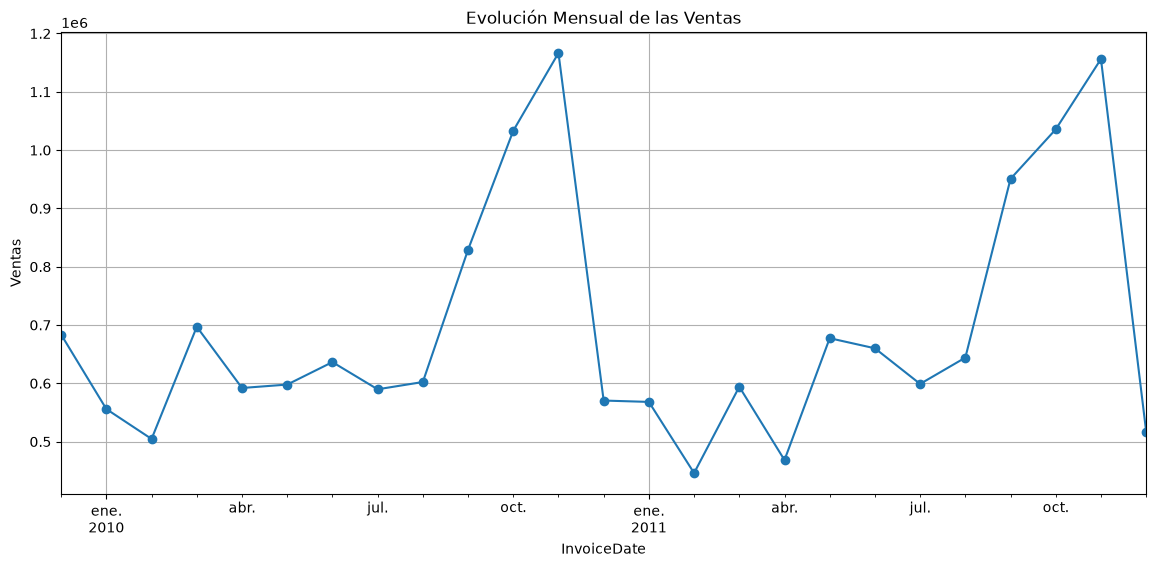

In [ ]:
# Evolución mensual de las ventas

ventas_mes = (
    df_clean
    .groupby(pd.Grouper(key="InvoiceDate", freq="ME"))["Total"]
    .sum()
)

plt.figure(figsize=(14,6))

ventas_mes.plot(marker="o")

plt.title("Evolución Mensual de las Ventas")

plt.ylabel("Ventas")

plt.grid(True)

plt.show()

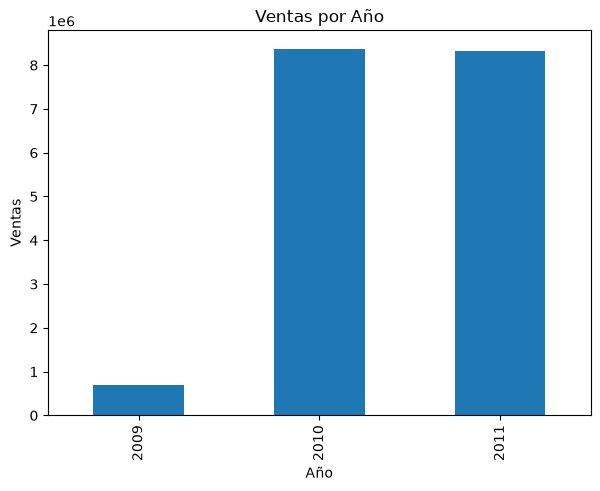

In [85]:
# Ventas por año

ventas_anio = (
    df_clean
    .groupby("Año")["Total"]
    .sum()
)

plt.figure(figsize=(7,5))

ventas_anio.plot(kind="bar")

plt.title("Ventas por Año")

plt.ylabel("Ventas")

plt.show()

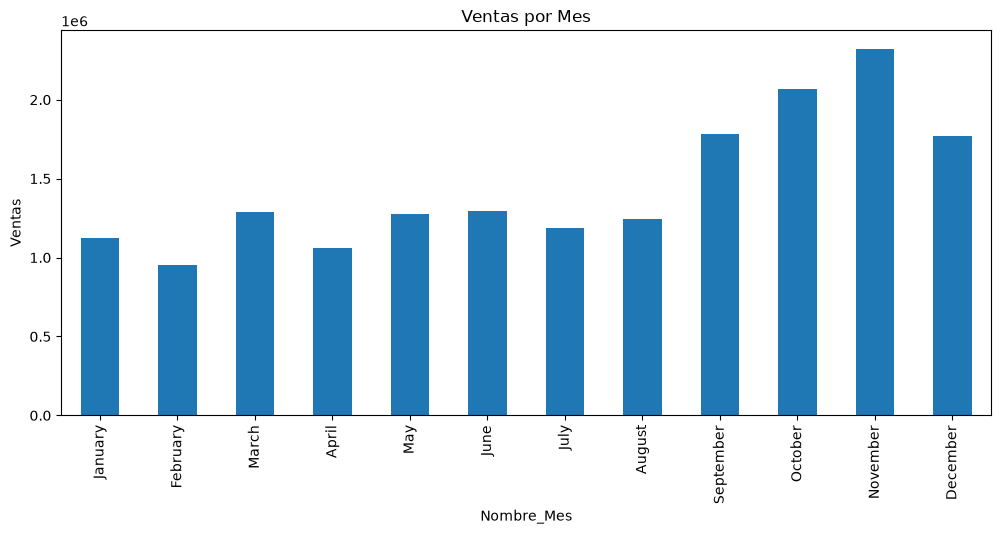

In [87]:
# Ventas  por Mes
orden_meses = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

ventas_mes_nombre = (
    df_clean
    .groupby("Nombre_Mes")["Total"]
    .sum()
    .reindex(orden_meses)
)

plt.figure(figsize=(12,5))

ventas_mes_nombre.plot(kind="bar")

plt.title("Ventas por Mes")

plt.ylabel("Ventas")

plt.show()

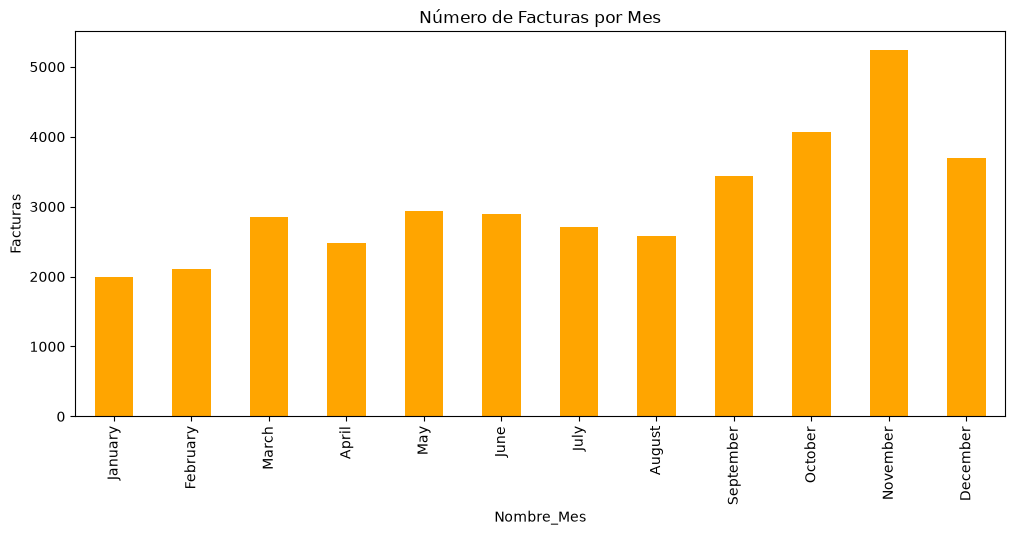

In [88]:
facturas_mes = (
    df_clean
    .groupby("Nombre_Mes")["Invoice"]
    .nunique()
    .reindex(orden_meses)
)

plt.figure(figsize=(12,5))

facturas_mes.plot(kind="bar", color="orange")

plt.title("Número de Facturas por Mes")

plt.ylabel("Facturas")

plt.show()

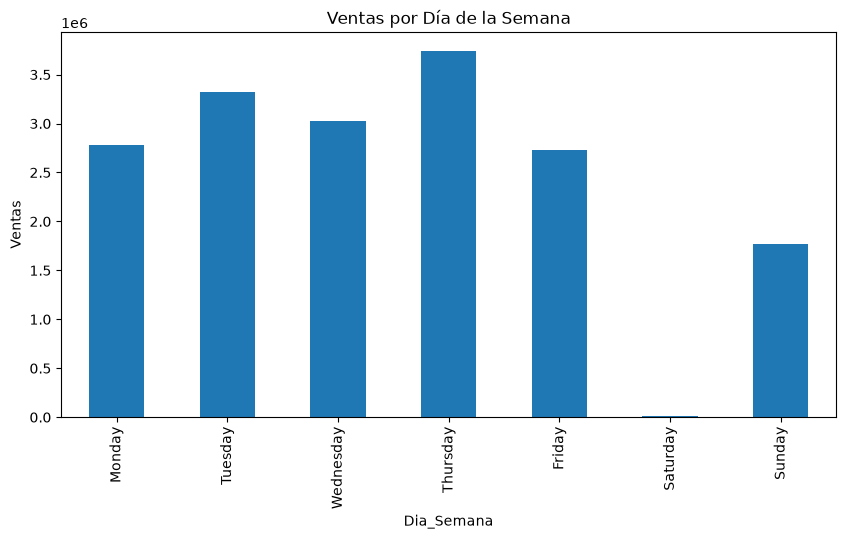

In [89]:
orden_dias = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

ventas_dia = (
    df_clean
    .groupby("Dia_Semana")["Total"]
    .sum()
    .reindex(orden_dias)
)

plt.figure(figsize=(10,5))

ventas_dia.plot(kind="bar")

plt.title("Ventas por Día de la Semana")

plt.ylabel("Ventas")

plt.show()

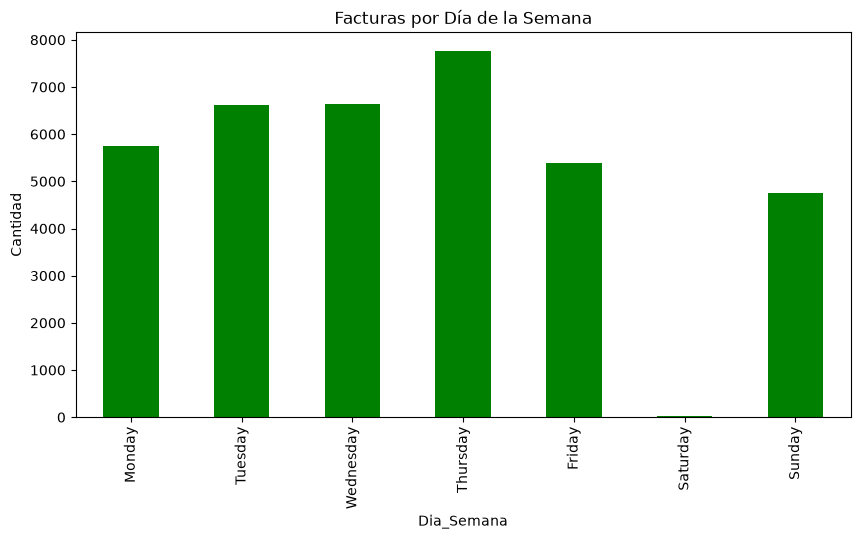

In [90]:
facturas_dia = (
    df_clean
    .groupby("Dia_Semana")["Invoice"]
    .nunique()
    .reindex(orden_dias)
)

plt.figure(figsize=(10,5))

facturas_dia.plot(kind="bar", color="green")

plt.title("Facturas por Día de la Semana")

plt.ylabel("Cantidad")

plt.show()

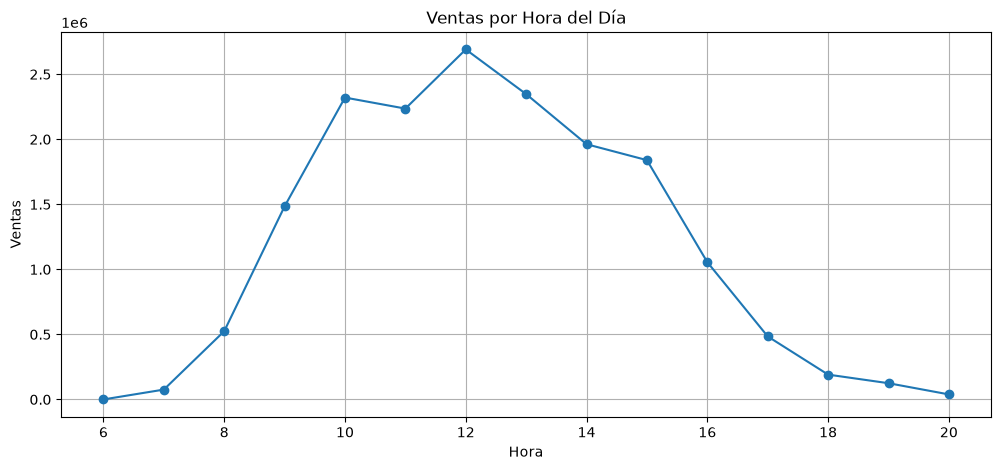

In [91]:
ventas_hora = (
    df_clean
    .groupby("Hora")["Total"]
    .sum()
)

plt.figure(figsize=(12,5))

ventas_hora.plot(marker="o")

plt.title("Ventas por Hora del Día")

plt.xlabel("Hora")

plt.ylabel("Ventas")

plt.grid(True)

plt.show()

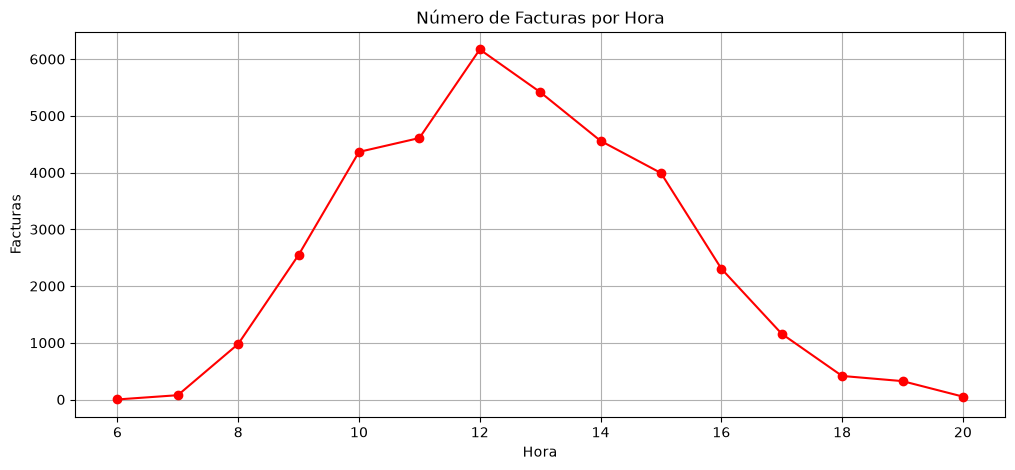

In [92]:
facturas_hora = (
    df_clean
    .groupby("Hora")["Invoice"]
    .nunique()
)

plt.figure(figsize=(12,5))

facturas_hora.plot(marker="o", color="red")

plt.title("Número de Facturas por Hora")

plt.xlabel("Hora")

plt.ylabel("Facturas")

plt.grid(True)

plt.show()

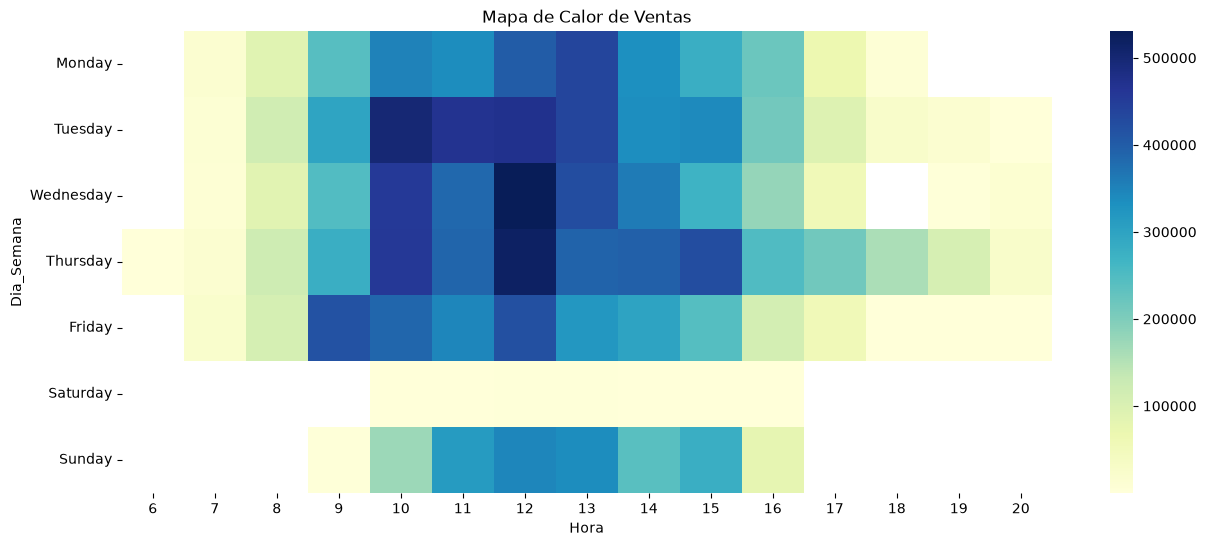

In [93]:
import seaborn as sns

heat = df_clean.pivot_table(
    values="Total",
    index="Dia_Semana",
    columns="Hora",
    aggfunc="sum"
)

heat = heat.reindex(orden_dias)

plt.figure(figsize=(15,6))

sns.heatmap(
    heat,
    cmap="YlGnBu"
)

plt.title("Mapa de Calor de Ventas")

plt.show()

In [94]:
resumen_temporal = pd.DataFrame({
    "Indicador":[
        "Periodo analizado",
        "Número de años",
        "Número de meses",
        "Primer registro",
        "Último registro"
    ],
    "Valor":[
        f"{df_clean['InvoiceDate'].min().date()} - {df_clean['InvoiceDate'].max().date()}",
        df_clean["Año"].nunique(),
        df_clean["Nombre_Mes"].nunique(),
        df_clean["InvoiceDate"].min(),
        df_clean["InvoiceDate"].max()
    ]
})

display(resumen_temporal)

,Indicador,Valor
0,Periodo analizado,2009-12-01 - 2011-12-09
1,Número de años,3
2,Número de meses,12
3,Primer registro,2009-12-01 07:45:00
4,Último registro,2011-12-09 12:50:00


# Conclusiones del Análisis Temporal

El análisis temporal permitió comprender el comportamiento de las ventas durante el período comprendido entre **diciembre de 2009 y diciembre de 2011**, identificando patrones estacionales, horarios de mayor actividad y días con mayor volumen de transacciones.

## 1. Evolución mensual de las ventas

La evolución de las ventas evidencia un comportamiento relativamente estable durante la mayor parte del año, con incrementos significativos en el último trimestre.

Los mayores picos de ventas se presentan entre **septiembre y noviembre**, alcanzando el máximo durante **noviembre** en ambos años analizados.

Posteriormente se observa una disminución en diciembre, la cual se explica porque el conjunto de datos finaliza el **9 de diciembre de 2011**, por lo que dicho mes no contiene información completa.

Este comportamiento confirma la existencia de una marcada **estacionalidad comercial**, característica del sector retail, asociada a campañas de fin de año y temporadas de mayor consumo.

---

## 2. Ventas por año

El período de estudio comprende tres años calendario:

- **2009:** únicamente contiene información del mes de diciembre, por lo que sus ventas son considerablemente menores.
- **2010 y 2011:** presentan niveles de ventas muy similares, superiores a los ocho millones de unidades monetarias, evidenciando una operación estable durante ambos años.

La similitud entre 2010 y 2011 indica que el negocio mantiene un comportamiento consistente y que los patrones encontrados son representativos del funcionamiento habitual de la empresa.

---

## 3. Ventas por mes

El análisis mensual muestra una clara estacionalidad.

Los meses con mayor facturación corresponden a:

1. **Noviembre**
2. **Octubre**
3. **Septiembre**
4. **Diciembre** *(considerando que 2011 está incompleto)*

Por el contrario, los meses de **enero**, **febrero** y **abril** presentan los menores niveles de ventas.

Estos resultados reflejan el incremento natural de la demanda durante el último trimestre del año, impulsado por campañas comerciales y compras asociadas a la temporada navideña.

---

## 4. Número de facturas por mes

El comportamiento del número de facturas es consistente con el análisis de ventas.

Noviembre registra el mayor volumen de transacciones, seguido por octubre y diciembre.

Este resultado indica que el incremento en las ventas no solo obedece a compras de mayor valor, sino también a un aumento en el número de clientes y pedidos realizados durante estos meses.

---

## 5. Ventas por día de la semana

Las ventas presentan diferencias importantes entre los días de la semana.

Los días con mayor actividad comercial son:

- **Jueves**
- **Martes**
- **Miércoles**

En contraste, **sábado** prácticamente no registra ventas y **domingo** presenta un volumen considerablemente inferior al resto de la semana.

Este comportamiento es coherente con un negocio orientado principalmente al mercado empresarial (B2B), donde la mayor actividad se concentra durante los días laborales.

---

## 6. Número de facturas por día de la semana

El número de facturas confirma el patrón observado anteriormente.

El mayor número de pedidos se concentra entre **martes y jueves**, alcanzando su máximo el **jueves**.

Durante el sábado prácticamente no se registran transacciones, mientras que el domingo presenta una actividad reducida.

Esto sugiere que las operaciones comerciales se desarrollan principalmente durante la semana laboral.

---

## 7. Ventas por hora

El comportamiento horario evidencia una concentración muy marcada de las ventas.

Las compras comienzan alrededor de las **08:00**, aumentan rápidamente durante la mañana y alcanzan su punto máximo aproximadamente a las **12:00**.

Posteriormente las ventas disminuyen de forma gradual hasta finalizar la jornada comercial.

Este patrón indica que la mayor actividad de los clientes ocurre durante el horario laboral.

---

## 8. Número de facturas por hora

El número de pedidos sigue prácticamente la misma tendencia que las ventas.

La mayor cantidad de facturas se registra entre las **10:00 y las 14:00 horas**, con un máximo alrededor del mediodía.

Después de las **16:00** se observa una disminución considerable en la actividad comercial.

---

## 9. Mapa de calor

El mapa de calor integra la información por día y hora, permitiendo identificar los momentos de mayor actividad comercial.

Se observa una fuerte concentración de ventas entre:

- **Martes, miércoles y jueves**
- **10:00 y 15:00 horas**

Estas franjas representan el período de mayor demanda del negocio.

Por el contrario, durante los fines de semana y las primeras horas de la mañana la actividad comercial es significativamente menor.

---

# Implicaciones para el Sistema de Recomendación

Aunque el algoritmo **FP-Growth** no utiliza variables temporales durante el entrenamiento, el análisis temporal aporta información valiosa para futuras estrategias comerciales.

Los principales hallazgos permiten concluir que:

- Existe una **estacionalidad claramente definida**, con un incremento importante de las ventas durante el último trimestre del año.
- Las campañas de recomendaciones pueden priorizar los meses de **septiembre, octubre y noviembre**, donde se concentra la mayor demanda.
- Las recomendaciones pueden mostrarse con mayor frecuencia durante las horas de mayor actividad (**10:00 a 15:00**), aumentando la probabilidad de interacción por parte del cliente.
- Los resultados también permiten desarrollar futuras recomendaciones estacionales, ajustando las promociones según la época del año.

En conjunto, el análisis temporal demuestra que el comportamiento de compra no es uniforme a lo largo del tiempo y proporciona información estratégica que puede complementar el sistema de recomendación basado en **FP-Growth**, permitiendo incorporar reglas de negocio orientadas a campañas comerciales, temporadas de alta demanda y horarios de mayor actividad.

# 8. Análisis de Clientes

## Objetivo

El análisis de clientes tiene como propósito comprender el comportamiento de compra de los consumidores a partir de su historial de transacciones.

Este análisis permite conocer la estructura de la base de clientes, identificar compradores frecuentes y reconocer aquellos que generan un mayor valor para el negocio.

En esta sección se responderán las siguientes preguntas:

- ¿Cuántos clientes únicos existen?
- ¿Quiénes realizan el mayor número de compras?
- ¿Quiénes generan mayores ingresos?
- ¿Cuál es el gasto promedio por cliente?
- ¿Cómo se distribuye la frecuencia de compra?
- ¿Existen clientes con comportamientos atípicos?

In [ ]:
# Número de clientes
clientes = df_clean["Customer ID"].nunique()

print(f"Número de clientes únicos: {clientes:,}")

Número de clientes únicos: 5,878


In [96]:
# Clientes con mayor número de compras

clientes_compras = (
    df_clean
    .groupby("Customer ID")["Invoice"]
    .nunique()
    .sort_values(ascending=False)
)

clientes_compras.head(20)

Customer ID
14911.0    398
12748.0    336
17841.0    211
15311.0    208
13089.0    203
14606.0    192
14156.0    156
17850.0    155
14646.0    151
18102.0    145
13694.0    143
15061.0    127
14527.0    122
17949.0    118
12971.0    116
13798.0    110
16422.0    109
16029.0    107
13408.0    106
17961.0    100
Name: Invoice, dtype: int64

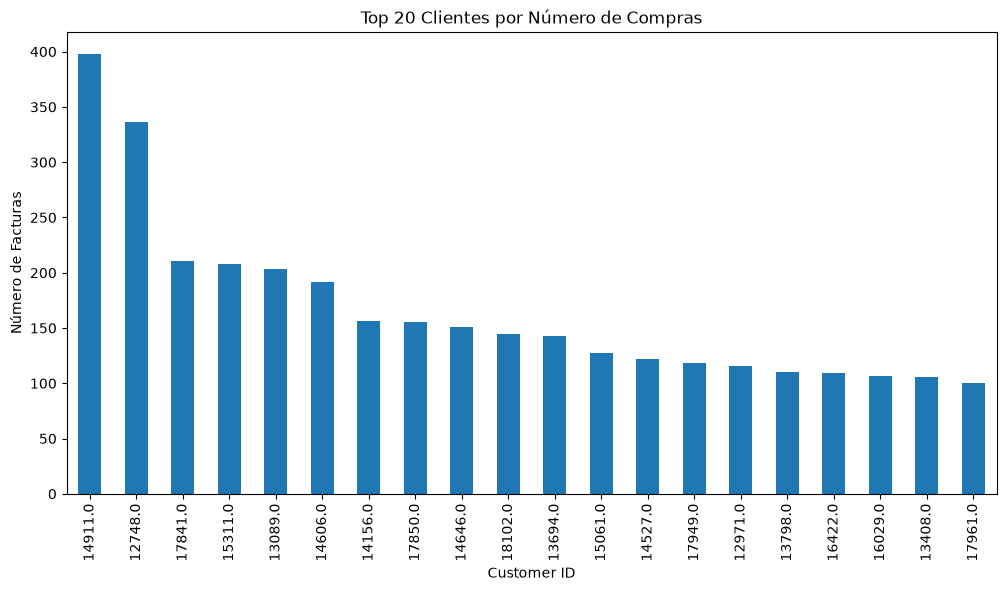

In [97]:
plt.figure(figsize=(12,6))

clientes_compras.head(20).plot(kind="bar")

plt.title("Top 20 Clientes por Número de Compras")

plt.xlabel("Customer ID")

plt.ylabel("Número de Facturas")

plt.show()

In [98]:
# Clientes con mayor facturación

clientes_ventas = (
    df_clean
    .groupby("Customer ID")["Total"]
    .sum()
    .sort_values(ascending=False)
)

clientes_ventas.head(20)

Customer ID
18102.0    580987.04
14646.0    528602.52
14156.0    313437.62
14911.0    291420.81
17450.0    244784.25
13694.0    195640.69
17511.0    172132.87
16446.0    168472.50
16684.0    147142.77
12415.0    144458.37
15061.0    126389.02
16029.0    117763.62
17949.0    117314.08
15311.0    114966.42
13089.0    113416.91
12931.0     92347.34
14298.0     91194.49
15769.0     88612.52
12346.0     77556.46
13798.0     75428.87
Name: Total, dtype: float64

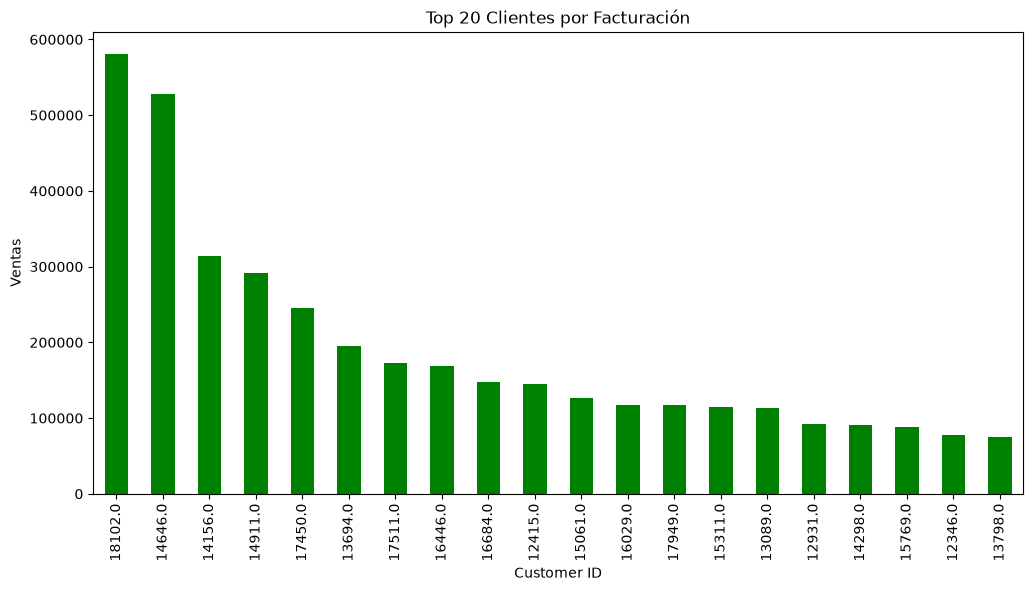

In [99]:
plt.figure(figsize=(12,6))

clientes_ventas.head(20).plot(kind="bar", color="green")

plt.title("Top 20 Clientes por Facturación")

plt.ylabel("Ventas")

plt.show()

In [100]:
# Distribución del gasto por cliente

ventas_cliente = (
    df_clean
    .groupby("Customer ID")["Total"]
    .sum()
)

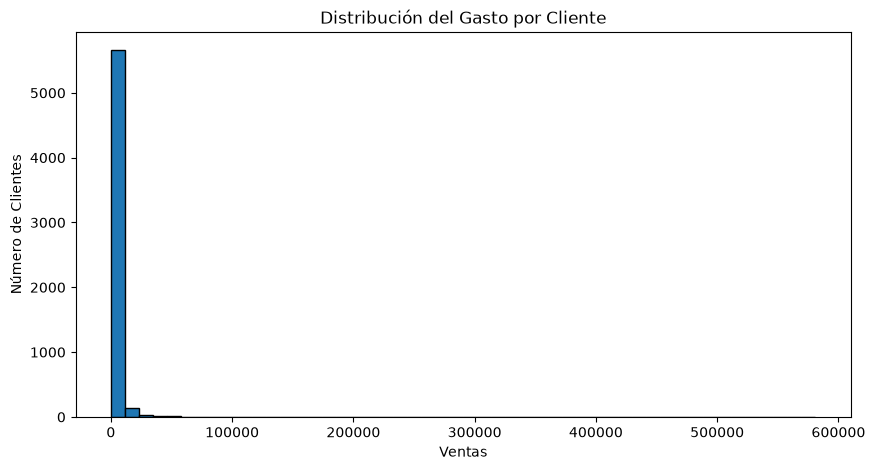

In [101]:
plt.figure(figsize=(10,5))

plt.hist(
    ventas_cliente,
    bins=50,
    edgecolor="black"
)

plt.title("Distribución del Gasto por Cliente")

plt.xlabel("Ventas")

plt.ylabel("Número de Clientes")

plt.show()

In [102]:
# Distribución de la frecuencia de compra

frecuencia_cliente = (
    df_clean
    .groupby("Customer ID")["Invoice"]
    .nunique()
)

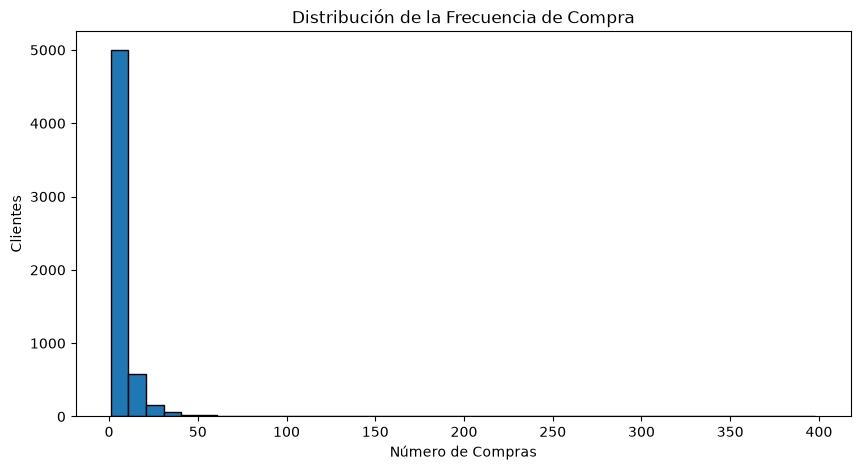

In [103]:
plt.figure(figsize=(10,5))

plt.hist(
    frecuencia_cliente,
    bins=40,
    edgecolor="black"
)

plt.title("Distribución de la Frecuencia de Compra")

plt.xlabel("Número de Compras")

plt.ylabel("Clientes")

plt.show()

In [ ]:
# Ticket promedio por cliente
ticket_cliente = (
    df_clean
    .groupby("Customer ID")
    .agg({
        "Total":"sum",
        "Invoice":"nunique"
    })
)

ticket_cliente["Ticket_Promedio"] = (
    ticket_cliente["Total"] /
    ticket_cliente["Invoice"]
)

ticket_cliente.head()

,Total,Invoice,Ticket_Promedio
Customer ID,,,
12346.0,77556.46,12,6463.038333
12347.0,4921.53,8,615.191250
12348.0,2019.40,5,403.880000
12349.0,4428.69,4,1107.172500
12350.0,334.40,1,334.400000


In [105]:
ticket_cliente["Ticket_Promedio"].describe()

count     5878.000000
mean       385.180841
std       1214.286459
min          2.950000
25%        176.682500
50%        279.242679
75%        414.902458
max      84236.250000
Name: Ticket_Promedio, dtype: float64

In [106]:
# Top clientes por ticket promedio
ticket_cliente.sort_values(
    "Ticket_Promedio",
    ascending=False
).head(20)

,Total,Invoice,Ticket_Promedio
Customer ID,,,
16446.0,168472.50,2,84236.250000
15749.0,44534.30,3,14844.766667
15098.0,39916.50,3,13305.500000
13687.0,11880.84,1,11880.840000
12918.0,10953.50,1,10953.500000
18052.0,10877.18,1,10877.180000
15760.0,13916.34,2,6958.170000
13902.0,34095.26,5,6819.052000
12346.0,77556.46,12,6463.038333


In [107]:
resumen_clientes = pd.DataFrame({

"Indicador":[

"Clientes únicos",

"Ventas promedio por cliente",

"Compras promedio por cliente",

"Ticket promedio"

],

"Valor":[

df_clean["Customer ID"].nunique(),

round(ventas_cliente.mean(),2),

round(frecuencia_cliente.mean(),2),

round(ticket_cliente["Ticket_Promedio"].mean(),2)

]

})

display(resumen_clientes)

,Indicador,Valor
0,Clientes únicos,5878.00
1,Ventas promedio por cliente,2955.90
2,Compras promedio por cliente,6.29
3,Ticket promedio,385.18


C:\Users\druiz\AppData\Local\Temp\ipykernel_20088\3100191439.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


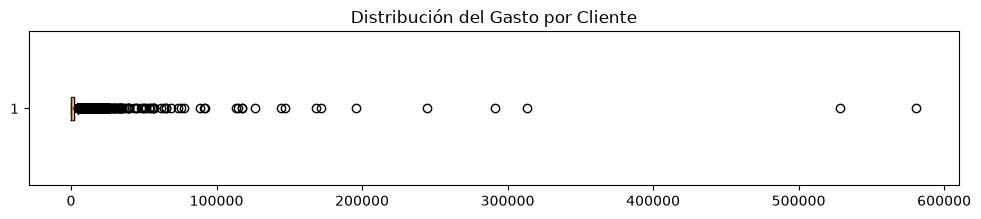

In [108]:
plt.figure(figsize=(12,2))

plt.boxplot(
    ventas_cliente,
    vert=False
)

plt.title("Distribución del Gasto por Cliente")

plt.show()

C:\Users\druiz\AppData\Local\Temp\ipykernel_20088\349372053.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


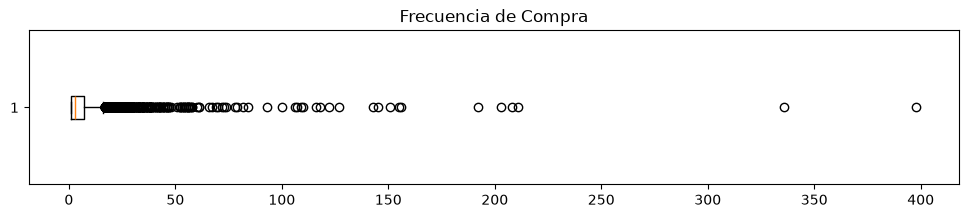

In [109]:
plt.figure(figsize=(12,2))

plt.boxplot(
    frecuencia_cliente,
    vert=False
)

plt.title("Frecuencia de Compra")

plt.show()

# Conclusiones del Análisis de Clientes

El análisis de clientes permitió caracterizar el comportamiento de compra de los consumidores y comprender cómo se distribuyen las ventas dentro de la empresa.

Durante el período comprendido entre diciembre de 2009 y diciembre de 2011 se identificaron **5.878 clientes únicos**, los cuales realizaron en promedio **6,29 compras** y generaron un gasto promedio cercano a **2.956 unidades monetarias** por cliente.

| Indicador | Valor |
|-----------|------:|
| Clientes únicos | **5.878** |
| Compras promedio por cliente | **6,29** |
| Ventas promedio por cliente | **2.955,90** |
| Ticket promedio por factura | **385,18** |

---

## 1. Tamaño de la base de clientes

El conjunto de datos contiene **5.878 clientes únicos**, lo que representa una base de clientes suficientemente amplia para analizar diferentes comportamientos de compra y validar posteriormente el sistema de recomendaciones.

La diversidad de clientes permite identificar tanto compradores ocasionales como clientes altamente recurrentes, enriqueciendo el análisis exploratorio.

---

## 2. Frecuencia de compra

En promedio, cada cliente realizó **6,29 compras** durante el período analizado.

No obstante, la distribución de la frecuencia de compra es altamente asimétrica.

El diagrama de caja evidencia que:

- La mayoría de los clientes realiza pocas compras.
- Existe un grupo reducido de clientes altamente recurrentes.
- Algunos clientes superan las **400 facturas**, convirtiéndose en compradores estratégicos para la empresa.

Este comportamiento corresponde al conocido principio de **Pareto**, donde una pequeña proporción de clientes concentra una parte importante de la actividad comercial.

---

## 3. Gasto por cliente

El gasto promedio por cliente fue de aproximadamente **2.956** unidades monetarias.

Sin embargo, el boxplot muestra una elevada dispersión y una importante presencia de valores atípicos.

Se identifican clientes que superan ampliamente los **500.000** en ventas acumuladas, mientras que la mayoría registra valores considerablemente menores.

Esta distribución evidencia que:

- Existe un pequeño grupo de clientes con un alto valor económico.
- La mayoría de los compradores realiza pedidos de menor monto.
- La distribución presenta una fuerte asimetría positiva, típica del comercio electrónico y de empresas con clientes mayoristas.

---

## 4. Ticket promedio

El ticket promedio por factura es de **385,18** unidades monetarias.

Este indicador representa el valor promedio de cada compra realizada por los clientes y constituye un referente importante para evaluar futuras estrategias comerciales.

Incrementar este indicador será uno de los objetivos indirectos del sistema de recomendación mediante estrategias de **Cross Selling** y **Up Selling**.

---

## 5. Comportamiento de los clientes

Los resultados obtenidos permiten identificar tres perfiles generales de clientes:

- **Clientes ocasionales:** realizan pocas compras y presentan un gasto reducido.
- **Clientes recurrentes:** compran de manera periódica y generan ingresos constantes.
- **Clientes de alto valor:** concentran una parte significativa de las ventas y presentan una alta frecuencia de compra.

Esta distribución confirma que el negocio combina clientes minoristas con compradores de mayor volumen, situación consistente con la descripción original del conjunto de datos.

---

# Implicaciones para el Sistema de Recomendación

Aunque el algoritmo **FP-Growth** no utiliza directamente el identificador del cliente durante el entrenamiento, el análisis realizado aporta información valiosa para interpretar y validar los resultados del modelo.

Los principales hallazgos son:

- La existencia de clientes altamente recurrentes garantiza un número suficiente de transacciones para descubrir reglas de asociación robustas.
- Los clientes con mayor frecuencia de compra representan un grupo ideal para evaluar la utilidad de las recomendaciones generadas.
- El ticket promedio constituye un indicador de negocio que permitirá medir el impacto futuro del sistema de recomendación.
- La presencia de clientes de alto valor abre la posibilidad de implementar estrategias diferenciadas de Cross Selling y Up Selling basadas en los productos que suelen adquirirse conjuntamente.

En conjunto, el análisis confirma que la empresa presenta una base de clientes diversa, con patrones de compra claramente diferenciados y suficiente volumen transaccional para desarrollar un sistema de recomendaciones basado en **FP-Growth**, orientado a incrementar el valor promedio de cada compra y potenciar las ventas de productos relacionados.

# 9. Conclusiones del Análisis Exploratorio de Datos (EDA)

El Análisis Exploratorio de Datos (EDA) permitió comprender en profundidad las características del conjunto de datos **Online Retail II**, identificar problemas de calidad, conocer el comportamiento de los clientes y analizar los patrones de compra que servirán como base para el desarrollo del sistema de recomendación.

Durante el proceso se evaluaron aspectos relacionados con la calidad de los datos, las ventas, los productos, los clientes y el comportamiento temporal de las transacciones, obteniendo información relevante para la preparación del modelo de reglas de asociación mediante **FP-Growth**.

---

## 9.1 Calidad de los datos

El conjunto de datos original contenía **1.067.371 registros** correspondientes a transacciones realizadas entre diciembre de 2009 y diciembre de 2011.

Durante la evaluación de calidad se identificaron diferentes tipos de inconsistencias:

- Registros duplicados.
- Facturas canceladas.
- Cantidades negativas asociadas a devoluciones.
- Productos con precio igual o inferior a cero.
- Registros sin identificador de cliente.

Con el objetivo de garantizar la confiabilidad del análisis y del modelo de recomendación, se aplicó un proceso de limpieza que incluyó:

- Eliminación de registros duplicados.
- Eliminación de facturas canceladas.
- Eliminación de cantidades negativas.
- Eliminación de precios iguales o inferiores a cero.
- Eliminación de registros sin **Customer ID**.

Este proceso permitió construir un conjunto de datos consistente y adecuado para el análisis de patrones de compra.

---

## 9.2 Productos

El análisis de productos evidenció una alta concentración de las ventas en un grupo reducido de artículos.

Entre los productos con mayor volumen de ventas destacan:

- WORLD WAR 2 GLIDERS ASSTD DESIGNS
- WHITE HANGING HEART T-LIGHT HOLDER
- PAPER CRAFT, LITTLE BIRDIE
- ASSORTED COLOUR BIRD ORNAMENT
- MEDIUM CERAMIC TOP STORAGE JAR

Asimismo, el análisis de facturación mostró que algunos productos generan mayores ingresos debido a su precio unitario, aunque no necesariamente sean los más vendidos.

Esta diferencia evidencia la importancia de considerar tanto la frecuencia de compra como el valor económico de los productos para futuras estrategias comerciales.

---

## 9.3 Clientes

El análisis identificó una base de **5.878 clientes únicos**, quienes realizaron en promedio **6,29 compras** durante el período analizado.

Los principales indicadores fueron:

| Indicador | Valor |
|-----------|------:|
| Clientes únicos | **5.878** |
| Compras promedio por cliente | **6,29** |
| Ventas promedio por cliente | **2.955,90** |
| Ticket promedio | **385,18** |

La distribución del gasto y de la frecuencia de compra presentó una fuerte asimetría positiva.

La mayoría de los clientes realiza pocas compras, mientras que un pequeño grupo concentra una parte importante de las ventas del negocio.

Este comportamiento es consistente con el principio de Pareto y refleja la coexistencia de clientes minoristas y compradores mayoristas.

---

## 9.4 Comportamiento temporal

El análisis temporal permitió identificar patrones claros de comportamiento.

Los principales hallazgos fueron:

- El negocio presenta una marcada estacionalidad.
- Las mayores ventas se concentran entre **septiembre y noviembre**.
- Noviembre representa el mes con mayor volumen de ventas y de facturas.
- La mayor actividad comercial ocurre entre **martes y jueves**.
- El horario con mayor número de compras se encuentra entre las **10:00 y las 15:00 horas**, alcanzando su máximo alrededor del mediodía.

Estos resultados muestran que el comportamiento de compra no es uniforme durante el año y ofrecen oportunidades para futuras campañas comerciales estacionales.

---

## 9.5 Basket Analysis

Uno de los hallazgos más importantes del análisis exploratorio corresponde al estudio de las transacciones.

Se identificaron aproximadamente **36.969 facturas**, con un tamaño promedio de **20,8 productos por cesta de compra**.

La elevada cantidad de productos por transacción incrementa significativamente el número de combinaciones posibles entre artículos y constituye una condición favorable para aplicar algoritmos de reglas de asociación.

El análisis de coocurrencia mostró que determinados productos aparecen frecuentemente dentro de las mismas facturas, lo cual confirma la existencia de patrones de compra que pueden ser explotados mediante técnicas de **Market Basket Analysis**.

---

## 9.6 Hallazgos principales

El proceso de análisis permitió identificar los siguientes aspectos relevantes:

- El conjunto de datos posee un alto volumen de transacciones y una amplia variedad de productos.
- La calidad de los datos mejoró significativamente después del proceso de limpieza.
- Existe una alta concentración de ventas en un número reducido de productos.
- La empresa presenta una base de clientes amplia, con diferentes niveles de recurrencia y gasto.
- Se identificó una marcada estacionalidad tanto por mes como por día y hora.
- El tamaño promedio de la cesta de compra (20,8 productos) proporciona una gran riqueza de combinaciones entre artículos.
- La coocurrencia entre productos evidencia patrones de compra repetitivos que justifican el uso de algoritmos de reglas de asociación.

---

## 9.7 Conclusión general

Los resultados obtenidos durante el Análisis Exploratorio de Datos permiten concluir que el conjunto de datos **Online Retail II** reúne las condiciones necesarias para desarrollar un sistema de recomendación.

El elevado número de transacciones, la diversidad de productos, el tamaño de las cestas de compra y la existencia de patrones de coocurrencia entre artículos proporcionan una base sólida para descubrir reglas de asociación de alto valor comercial.

En consecuencia, la siguiente etapa del proyecto consistirá en preparar la matriz de transacciones y entrenar el algoritmo **FP-Growth**, con el objetivo de identificar productos que suelen comprarse conjuntamente y construir un sistema de recomendaciones orientado a estrategias de **Cross Selling** y **Up Selling**.

---


